# Análise Exploratória de Desastres Naturais no Brasil

Este notebook analisa registros de desastres naturais no Brasil a partir do Atlas Digital de Desastres, usando a aba de valores monetários corrigidos, e cruza os anos dos eventos com períodos de El Niño, La Niña e anos neutros. A análise busca identificar padrões temporais, territoriais, humanos e econômicos.

**Fontes dos dados**

- `data/raw/desastres-naturais-atlas-digital.xlsx`, com foco na aba `Atlas Valores Corrigidos`.
- `data/raw/el_nino_la_nina_eventos_1990_2025.csv`, com períodos ENSO entre 1990 e 2025.

**Período analisado**

O período efetivo é calculado a partir de `Data_Evento` no Atlas carregado localmente.

**Aviso metodológico**

O cruzamento com ENSO é temporal e exploratório. Ele compara anos classificados como El Niño, La Niña ou Neutro.

## 1. Importação de bibliotecas e configurações

Esta seção concentra imports, opções de exibição, tema visual e caminhos dos arquivos. O notebook usa apenas bibliotecas já previstas no ambiente do projeto.

In [5]:
from pathlib import Path
from IPython.display import Markdown, display
import io

import matplotlib

matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

sns.set_theme(style="whitegrid", palette="Set2", context="notebook")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11

ROOT = Path.cwd()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent

DATA_RAW = ROOT / "data" / "raw"
ATLAS_PATH = DATA_RAW / "desastres-naturais-atlas-digital.xlsx"
ENSO_PATH = DATA_RAW / "el_nino_la_nina_eventos_1990_2025.csv"

SHEET_ATLAS_CORRIGIDO = "Atlas Valores Corrigidos"
SHEET_GRUPOS = "Grupos de Desastres"

assert ATLAS_PATH.exists(), f"Arquivo não encontrado: {ATLAS_PATH}"
assert ENSO_PATH.exists(), f"Arquivo não encontrado: {ENSO_PATH}"


## 2. Carregamento dos dados

A análise principal usa `Atlas Valores Corrigidos` porque os valores monetários já estão corrigidos pela metodologia do Atlas. As demais abas são inspecionadas para contexto, mas não são misturadas com os valores corrigidos.

In [6]:
excel = pd.ExcelFile(ATLAS_PATH)
sheet_names = excel.sheet_names
display(Markdown("**Abas disponíveis no Excel:**"))
display(pd.DataFrame({"aba": sheet_names}))

df_raw = pd.read_excel(ATLAS_PATH, sheet_name=SHEET_ATLAS_CORRIGIDO)
df_grupos = pd.read_excel(ATLAS_PATH, sheet_name=SHEET_GRUPOS)
df_enso_raw = pd.read_csv(ENSO_PATH)

display(Markdown("**Dimensões dos datasets carregados:**"))
display(
    pd.DataFrame(
        {
            "dataset": ["Atlas corrigido", "Grupos de desastres", "Eventos ENSO"],
            "linhas": [len(df_raw), len(df_grupos), len(df_enso_raw)],
            "colunas": [df_raw.shape[1], df_grupos.shape[1], df_enso_raw.shape[1]],
        }
    )
)

display(Markdown("**Primeiras linhas do Atlas corrigido:**"))
display(df_raw.head())
display(Markdown("**Amostra aleatória do Atlas corrigido:**"))
display(df_raw.sample(5, random_state=42))
display(Markdown("**Eventos ENSO:**"))
display(df_enso_raw.head())


**Abas disponíveis no Excel:**

,aba
0,Atlas Valores Originais
1,Cálculo Correção
2,Atlas Valores Corrigidos
3,Grupos de Desastres


**Dimensões dos datasets carregados:**

,dataset,linhas,colunas
0,Atlas corrigido,76191,70
1,Grupos de desastres,65,5
2,Eventos ENSO,26,7


**Primeiras linhas do Atlas corrigido:**

,Protocolo_S2iD,Nome_Municipio,Sigla_UF,regiao,Data_Registro,Data_Evento,Cod_Cobrade,tipologia,descricao_tipologia,grupo_de_desastre,Cod_IBGE_Mun,Setores Censitários,Status,DH_Descricao,DH_MORTOS,DH_FERIDOS,DH_ENFERMOS,DH_DESABRIGADOS,DH_DESALOJADOS,DH_DESAPARECIDOS,DH_AFETADOS_SECA_ESTIAGEM,DH_total_danos_humanos_diretos,DH_OUTROS AFETADOS,DM_Descricao,DM_Uni Habita Danificadas,DM_Uni Habita Destruidas,DM_Uni Habita Valor,DM_Inst Saúde Danificadas,DM_Inst Saúde Destruidas,DM_Inst Saúde Valor,DM_Inst Ensino Danificadas,DM_Inst Ensino Destruidas,DM_Inst Ensino Valor,DM_Inst Serviços Danificadas,DM_Inst Serviços Destruidas,DM_Inst Serviços Valor,DM_Inst Comuni Danificadas,DM_Inst Comuni Destruidas,DM_Inst Comuni Valor,DM_Obras de Infra Danificadas,DM_Obras de Infra Destruidas,DM_Obras de Infra Valor,DM_total_danos_materiais,DA_Descricao,DA_Polui/cont da água,DA_Polui/cont do ar,DA_Polui/cont do solo,DA_Dimi/exauri hídrico,DA_Incêndi parques/APA's/APP's,PEPL_Descricao,PEPL_Assis_méd e emergên(R$),PEPL_Abast de água pot(R$),PEPL_sist de esgotos sanit(R$),PEPL_Sis limp e rec lixo (R$),PEPL_Sis cont pragas (R$),PEPL_distrib energia (R$),PEPL_Telecomunicações (R$),PEPL_Tran loc/reg/l_curso (R$),PEPL_Distrib combustíveis(R$),PEPL_Segurança pública (R$),PEPL_Ensino (R$),PEPL_total_publico,PEPR_Descricao,PEPR_Agricultura (R$),PEPR_Pecuária (R$),PEPR_Indústria (R$),PEPR_Comércio (R$),PEPR_Serviços (R$),PEPR_total_privado,PE_PLePR
0,SC-D-4215406-14110-19910107,Salto Veloso,SC,Sul,1991-01-07,1991-01-07,14110,4,Estiagem e Seca,Climatológico,4215406,NaN,Registro,NaN,0,0,0,0,0,0,0,0,0,NaN,0,0,0.00,0.00,0,0.00,0.00,0,0.00,0,0,0.00,0,0,0.00,0.00,0.00,0.00,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,NaN,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1,RS-D-4313102-14110-19910112,Nova Palma,RS,Sul,1991-01-12,1991-01-12,14110,4,Estiagem e Seca,Climatológico,4313102,NaN,Registro,NaN,0,0,0,0,0,0,0,0,0,NaN,0,0,0.00,0.00,0,0.00,0.00,0,0.00,0,0,0.00,0,0,0.00,0.00,0.00,0.00,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,NaN,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2,RS-D-4304952-14110-19910115,Caseiros,RS,Sul,1991-01-15,1991-01-15,14110,4,Estiagem e Seca,Climatológico,4304952,NaN,Registro,NaN,0,0,0,0,0,0,0,0,0,NaN,0,0,0.00,0.00,0,0.00,0.00,0,0.00,0,0,0.00,0,0,0.00,0.00,0.00,0.00,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,NaN,0.00,0.00,0.00,0.00,0.00,0.00,0.00
3,SC-D-4208609-14110-19910115,Jaborá,SC,Sul,1991-01-15,1991-01-15,14110,4,Estiagem e Seca,Climatológico,4208609,NaN,Registro,NaN,0,0,0,0,0,0,0,0,0,NaN,0,0,0.00,0.00,0,0.00,0.00,0,0.00,0,0,0.00,0,0,0.00,0.00,0.00,0.00,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,NaN,0.00,0.00,0.00,0.00,0.00,0.00,0.00
4,SC-D-4207650-14110-19910118,Iporã do Oeste,SC,Sul,1991-01-18,1991-01-18,14110,4,Estiagem e Seca,Climatológico,4207650,NaN,Registro,NaN,0,0,0,0,0,0,0,0,0,NaN,0,0,0.00,0.00,0,0.00,0.00,0,0.00,0,0,0.00,0,0,0.00,0.00,0.00,0.00,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,NaN,0.00,0.00,0.00,0.00,0.00,0.00,0.00


**Amostra aleatória do Atlas corrigido:**

,Protocolo_S2iD,Nome_Municipio,Sigla_UF,regiao,Data_Registro,Data_Evento,Cod_Cobrade,tipologia,descricao_tipologia,grupo_de_desastre,Cod_IBGE_Mun,Setores Censitários,Status,DH_Descricao,DH_MORTOS,DH_FERIDOS,DH_ENFERMOS,DH_DESABRIGADOS,DH_DESALOJADOS,DH_DESAPARECIDOS,DH_AFETADOS_SECA_ESTIAGEM,DH_total_danos_humanos_diretos,DH_OUTROS AFETADOS,DM_Descricao,DM_Uni Habita Danificadas,DM_Uni Habita Destruidas,DM_Uni Habita Valor,DM_Inst Saúde Danificadas,DM_Inst Saúde Destruidas,DM_Inst Saúde Valor,DM_Inst Ensino Danificadas,DM_Inst Ensino Destruidas,DM_Inst Ensino Valor,DM_Inst Serviços Danificadas,DM_Inst Serviços Destruidas,DM_Inst Serviços Valor,DM_Inst Comuni Danificadas,DM_Inst Comuni Destruidas,DM_Inst Comuni Valor,DM_Obras de Infra Danificadas,DM_Obras de Infra Destruidas,DM_Obras de Infra Valor,DM_total_danos_materiais,DA_Descricao,DA_Polui/cont da água,DA_Polui/cont do ar,DA_Polui/cont do solo,DA_Dimi/exauri hídrico,DA_Incêndi parques/APA's/APP's,PEPL_Descricao,PEPL_Assis_méd e emergên(R$),PEPL_Abast de água pot(R$),PEPL_sist de esgotos sanit(R$),PEPL_Sis limp e rec lixo (R$),PEPL_Sis cont pragas (R$),PEPL_distrib energia (R$),PEPL_Telecomunicações (R$),PEPL_Tran loc/reg/l_curso (R$),PEPL_Distrib combustíveis(R$),PEPL_Segurança pública (R$),PEPL_Ensino (R$),PEPL_total_publico,PEPR_Descricao,PEPR_Agricultura (R$),PEPR_Pecuária (R$),PEPR_Indústria (R$),PEPR_Comércio (R$),PEPR_Serviços (R$),PEPR_total_privado,PE_PLePR
74048,AM-F-1303601-12100-20250603,Santa Isabel do Rio Negro,AM,Norte,2025-06-03 00:00:00,2025-06-03,12100,7,Inundações,Hidrológico,1303601,"130360105000015, 130360105000016, 130360105000...",Reconhecido,Considerando as informações contidas no Relató...,0,98,248,0,0,0,0,346,6208,Considerando o Relatório da Secretaria Municip...,2,1,"47,200.00",0.00,0,0.00,30.00,0,"519,000.00",0,0,0.00,0,0,0.00,1.00,0.00,"10,500.00","576,700.00",Conforme atestado no Relatório Técnico da Secr...,MAIS DE 20% DA POPULAÇÃO AFETADA,NaN,NaN,NaN,NaN,"Conforme, Relatório da SEMED, foram paralisada...",0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,"1,772,157.80","1,772,157.80",Tendo em vista que a magnitude do evento adver...,"4,037,000.00","33,000.00",0.00,0.00,0.00,"4,070,000.00","5,842,157.80"
46991,AL-F-2704104-14110-20181204,Lagoa da Canoa,AL,Nordeste,2018-12-07 16:20:38,2018-12-04,14110,4,Estiagem e Seca,Climatológico,2704104,NaN,Reconhecido,"A população rural com 11.250 pessoas, foi afet...",0,0,0,0,0,0,11250,11250,11250,NaN,0,0,0.00,0.00,0,0.00,0.00,0,0.00,0,0,0.00,0,0,0.00,0.00,0.00,0.00,0.00,Houve diminuição de água no solo (fontes de na...,NaN,NaN,NaN,NaN,NaN,Diante da falta de água potável nas comunidade...,0.00,"100,415.43",0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,"100,415.43","Em 2018, foram plantados 1.500 ha de mandioca,...","9,037,388.70","418,397.63",0.00,0.00,0.00,"9,455,786.33","9,556,201.76"
43521,PI-F-2211506-14110-20170703,Vera Mendes,PI,Nordeste,2017-07-10 22:44:06,2017-07-03,14110,4,Estiagem e Seca,Climatológico,2211506,"221150605000004, 221150605000006, 221150605000...",Reconhecido,TODA A POPULAÇÃO DO MUNICÍPIO FOI AFETADA DIRE...,0,0,0,0,0,0,2987,2987,2987,DADO A ESTIAGEM OS POÇOS E AÇUDES PÚBLICOS NÃO...,0,0,0.00,0.00,0,0.00,0.00,0,0.00,0,0,0.00,0,0,0.00,0.00,0.00,0.00,0.00,EM CONSEQUÊNCIA DAS POUCAS PRECIPITAÇÕES PLUVI...,NaN,NaN,NaN,NaN,NaN,Com a estiagem além de não ter sido reposto o ...,"175,739.90","354,179.16",0.00,0.00,0.00,"31,277.46",0.00,0.00,0.00,0.00,0.00,"561,196.52","A IRREGULARIDADE DO PERÍODO CHUVOSO, PROVOCOU ...","10,679,376.32","3,569,287.07",0.00,0.00,0.00,"14,248,663.39","14,809,859.90"
13312,CE-P-2311306-12100-20040205,Quixadá,CE,Nordeste,2004-02-05 00:00:00,2004-02-05,12100,7,Inundações,Hidrológico,2311306,NaN,Reconhecido,NaN,0,0,0,0,0,0,0,0,0,NaN,0,0,0.00,0.00,0,0.00,0.00,0,0.00,0,0,0.00,0,0,0.00,0.00,0.00,0.00,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,NaN,0.00,0.00,0.00,0.00,0.00,0.00,0.00
73521,SC-F-4207205-13214-20250410,Imaru

**Eventos ENSO:**

,periodo,ano_inicio,ano_fim,fenomeno,intensidade,intensidade_rank,sinal_oni
0,1991-92,1991,1992,El Niño,Strong,3,1
1,1994-95,1994,1995,El Niño,Moderate,2,1
2,1995-96,1995,1996,La Niña,Moderate,2,-1
3,1997-98,1997,1998,El Niño,Very Strong,4,1
4,1998-99,1998,1999,La Niña,Strong,3,-1


## 3. Análise inicial

Esta leitura ampla verifica estrutura, tipos, duplicados, nulos, datas, categorias e primeiras concentrações por ano, UF, região, grupo de desastre, tipologia e status.

In [7]:
display(Markdown("**Formato do Atlas corrigido:**"))
display(pd.DataFrame({"linhas": [df_raw.shape[0]], "colunas": [df_raw.shape[1]]}))

buffer = io.StringIO()
df_raw.info(buf=buffer)
display(Markdown("**Tipos e completude (`info`):**"))
print(buffer.getvalue())

display(Markdown("**Resumo numérico:**"))
display(df_raw.describe(include=[np.number]).T)

display(Markdown("**Resumo categórico:**"))
display(df_raw.describe(include=["object", "string"]).T)

duplicados = int(df_raw.duplicated().sum())
display(
    Markdown(f"**Registros duplicados completos:** {duplicados:,}".replace(",", "."))
)

nulos = (
    df_raw.isna()
    .agg(["sum", "mean"])
    .T.rename(columns={"sum": "nulos", "mean": "percentual"})
    .sort_values("percentual", ascending=False)
)
nulos["percentual"] = nulos["percentual"] * 100
display(Markdown("**Nulos por coluna:**"))
display(nulos)

datas = []
for coluna in ["Data_Evento", "Data_Registro"]:
    serie = pd.to_datetime(df_raw[coluna], errors="coerce")
    datas.append(
        {
            "coluna": coluna,
            "data_minima": serie.min(),
            "data_maxima": serie.max(),
            "datas_invalidas": int(serie.isna().sum()),
        }
    )
display(Markdown("**Intervalo das datas principais:**"))
display(pd.DataFrame(datas))

display(Markdown("**Registros por ano do evento:**"))
display(
    pd.to_datetime(df_raw["Data_Evento"], errors="coerce")
    .dt.year.value_counts()
    .sort_index()
    .to_frame("registros")
)
display(Markdown("**Registros por UF:**"))
display(df_raw["Sigla_UF"].value_counts().to_frame("registros"))
display(Markdown("**Registros por região:**"))
display(df_raw["regiao"].value_counts().to_frame("registros"))
display(Markdown("**Registros por grupo de desastre:**"))
display(df_raw["grupo_de_desastre"].value_counts().to_frame("registros"))
display(Markdown("**Registros por tipologia:**"))
display(df_raw["descricao_tipologia"].value_counts().to_frame("registros"))
display(Markdown("**Status dos registros:**"))
display(df_raw["Status"].value_counts().to_frame("registros"))


**Formato do Atlas corrigido:**

,linhas,colunas
0,76191,70


**Tipos e completude (`info`):**

<class 'pandas.DataFrame'>
RangeIndex: 76191 entries, 0 to 76190
Data columns (total 70 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   Protocolo_S2iD                  76191 non-null  str           
 1   Nome_Municipio                  76191 non-null  str           
 2   Sigla_UF                        76191 non-null  str           
 3   regiao                          76191 non-null  str           
 4   Data_Registro                   76191 non-null  datetime64[us]
 5   Data_Evento                     76191 non-null  datetime64[us]
 6   Cod_Cobrade                     76191 non-null  int64         
 7   tipologia                       76191 non-null  int64         
 8   descricao_tipologia             76191 non-null  str           
 9   grupo_de_desastre               76191 non-null  str           
 10  Cod_IBGE_Mun                    76191 non-null  int64         
 11  Setores Censi

**Resumo numérico:**

...

,registros
grupo_de_desastre,
Climatológico,37260
Hidrológico,29353
Meteorológico,7330
Outros,2248


**Registros por tipologia:**

,registros
descricao_tipologia,
Estiagem e Seca,33493
Enxurradas,9854
Chuvas Intensas,9154
Inundações,6430
Vendavais e Ciclones,4885
Incêndio Florestal,3419
Granizo,2284
Alagamentos,2144
Movimento de Massa,1771


**Status dos registros:**

,registros
Status,
Registro,40583
Reconhecido,35608


**Observações da análise inicial**

- As colunas essenciais combinam identificadores, geografia, datas, tipologia, status e métricas com prefixos `DH_`, `DM_`, `PEPL_` e `PEPR_`.
- Os campos descritivos de danos e prejuízos têm muitos nulos, o que é esperado quando não há texto livre informado.
- Campos como `Protocolo_S2iD`, `Cod_Cobrade`, `Cod_IBGE_Mun` e `Setores Censitários` são úteis para rastreabilidade, mas não são eixos principais de visualização.
- `Data_Evento` representa quando o desastre ocorreu; `Data_Registro` representa quando o registro foi formalizado. As duas datas podem divergir e devem ser mantidas separadas.
- A normalização de `Sigla_UF` e strings categóricas evita inconsistências como espaços extras ou variações de caixa.

## 4. Tratamentos dos dados

Os tratamentos preservam o número de linhas. Não são removidos registros por padrão, não há descarte de `Status == "Registro"` e datas ausentes não são inventadas. Nulos numéricos são tratados como zero apenas para permitir agregações.

In [8]:
linhas_antes = len(df_raw)
df = df_raw.copy()

for coluna in ["Data_Registro", "Data_Evento"]:
    df[coluna] = pd.to_datetime(df[coluna], errors="coerce")

string_cols = df.select_dtypes(include=["object", "string"]).columns
for coluna in string_cols:
    df[coluna] = df[coluna].astype("string").str.strip()

df["Sigla_UF"] = df["Sigla_UF"].str.upper()

df["ano_evento"] = df["Data_Evento"].dt.year.astype("Int64")
df["mes_evento"] = df["Data_Evento"].dt.month.astype("Int64")
df["mes_nome"] = df["Data_Evento"].dt.month_name(locale=None)
meses_pt = {
    "January": "Janeiro",
    "February": "Fevereiro",
    "March": "Março",
    "April": "Abril",
    "May": "Maio",
    "June": "Junho",
    "July": "Julho",
    "August": "Agosto",
    "September": "Setembro",
    "October": "Outubro",
    "November": "Novembro",
    "December": "Dezembro",
}
df["mes_nome"] = df["mes_nome"].map(meses_pt)
df["ano_mes_evento"] = df["Data_Evento"].dt.to_period("M").astype("string")
df["trimestre_evento"] = "T" + df["Data_Evento"].dt.quarter.astype("Int64").astype(
    "string"
)
df["municipio_uf"] = (
    df["Nome_Municipio"].astype("string") + "-" + df["Sigla_UF"].astype("string")
)

description_cols = [
    col for col in df.columns if col.endswith("Descricao") or col.endswith("_Descricao")
]
metric_prefixes = ("DH_", "DM_", "PEPL_", "PEPR_")
metric_cols = [
    col
    for col in df.columns
    if (col.startswith(metric_prefixes) or col == "PE_PLePR")
    and col not in description_cols
]

for coluna in metric_cols:
    df[coluna] = pd.to_numeric(df[coluna], errors="coerce").fillna(0)

for coluna in description_cols:
    df[coluna] = df[coluna].fillna("Sem descrição")

linhas_depois = len(df)
impacto = pd.DataFrame(
    {
        "etapa": ["antes", "depois"],
        "linhas": [linhas_antes, linhas_depois],
        "colunas": [df_raw.shape[1], df.shape[1]],
    }
)
display(impacto)
display(
    Markdown(f"Linhas removidas pelo tratamento: **{linhas_antes - linhas_depois}**.")
)

display(Markdown("**Amostra após tratamentos:**"))
display(
    df[
        [
            "Nome_Municipio",
            "Sigla_UF",
            "regiao",
            "Data_Evento",
            "ano_evento",
            "mes_nome",
            "municipio_uf",
        ]
    ].head()
)


,etapa,linhas,colunas
0,antes,76191,70
1,depois,76191,76


Linhas removidas pelo tratamento: **0**.

**Amostra após tratamentos:**

,Nome_Municipio,Sigla_UF,regiao,Data_Evento,ano_evento,mes_nome,municipio_uf
0,Salto Veloso,SC,Sul,1991-01-07,1991,Janeiro,Salto Veloso-SC
1,Nova Palma,RS,Sul,1991-01-12,1991,Janeiro,Nova Palma-RS
2,Caseiros,RS,Sul,1991-01-15,1991,Janeiro,Caseiros-RS
3,Jaborá,SC,Sul,1991-01-15,1991,Janeiro,Jaborá-SC
4,Iporã do Oeste,SC,Sul,1991-01-18,1991,Janeiro,Iporã do Oeste-SC


## 5. Escolha das colunas úteis

As colunas são organizadas por finalidade analítica. O dataframe final mantém rastreabilidade, geografia, tempo, classificação do desastre e métricas de danos/prejuízos. Colunas fora desses grupos não entram no dataframe analítico apenas por não serem usadas nas análises seguintes.

In [9]:
id_cols = ["Protocolo_S2iD", "Cod_Cobrade", "Cod_IBGE_Mun", "Setores Censitários"]
geo_cols = ["Nome_Municipio", "Sigla_UF", "regiao", "Cod_IBGE_Mun", "municipio_uf"]
temporal_cols = [
    "Data_Registro",
    "Data_Evento",
    "ano_evento",
    "mes_evento",
    "mes_nome",
    "ano_mes_evento",
    "trimestre_evento",
]
disaster_cols = [
    "Cod_Cobrade",
    "tipologia",
    "descricao_tipologia",
    "grupo_de_desastre",
    "Status",
]
human_cols = [col for col in df.columns if col.startswith("DH_")]
material_cols = [col for col in df.columns if col.startswith("DM_")]
environmental_cols = [col for col in df.columns if col.startswith("DA_")]
public_loss_cols = [col for col in df.columns if col.startswith("PEPL_")]
private_loss_cols = [col for col in df.columns if col.startswith("PEPR_")] + [
    "PE_PLePR"
]

column_groups = {
    "Identificação": id_cols,
    "Geográficas": geo_cols,
    "Temporais": temporal_cols,
    "Categóricas de desastre": disaster_cols,
    "Danos humanos": human_cols,
    "Danos materiais": material_cols,
    "Danos ambientais": environmental_cols,
    "Prejuízo público": public_loss_cols,
    "Prejuízo privado": private_loss_cols,
}

display(
    pd.DataFrame(
        [(grupo, col) for grupo, cols in column_groups.items() for col in cols],
        columns=["grupo", "coluna"],
    )
)

useful_cols = []
for cols in column_groups.values():
    useful_cols.extend(cols)
useful_cols = list(dict.fromkeys([col for col in useful_cols if col in df.columns]))

df_analitico = df[useful_cols].copy()
display(Markdown(f"**Total de colunas no dataframe analítico:** {len(useful_cols)}"))
display(pd.DataFrame({"colunas_escolhidas": useful_cols}))


,grupo,coluna
0,Identificação,Protocolo_S2iD
1,Identificação,Cod_Cobrade
2,Identificação,Cod_IBGE_Mun
3,Identificação,Setores Censitários
4,Geográficas,Nome_Municipio
5,Geográficas,Sigla_UF
6,Geográficas,regiao
7,Geográficas,Cod_IBGE_Mun
8,Geográficas,municipio_uf
9,Temporais,Data_Registro


**Total de colunas no dataframe analítico:** 76

,colunas_escolhidas
0,Protocolo_S2iD
1,Cod_Cobrade
2,Cod_IBGE_Mun
3,Setores Censitários
4,Nome_Municipio
5,Sigla_UF
6,regiao
7,municipio_uf
8,Data_Registro
9,Data_Evento


## 6. Variáveis derivadas

As variáveis derivadas consolidam métricas recorrentes para simplificar rankings, KPIs e comparações. Também são criadas tabelas longas para categorias de danos materiais e prejuízos públicos/privados.

In [10]:
df_analitico["feridos_enfermos"] = (
    df_analitico["DH_FERIDOS"] + df_analitico["DH_ENFERMOS"]
)
df_analitico["desabrigados_desalojados"] = (
    df_analitico["DH_DESABRIGADOS"] + df_analitico["DH_DESALOJADOS"]
)
df_analitico["prejuizo_total"] = (
    df_analitico["PEPL_total_publico"] + df_analitico["PEPR_total_privado"]
)
df_analitico["danos_e_prejuizos_total"] = (
    df_analitico["DM_total_danos_materiais"]
    + df_analitico["PEPL_total_publico"]
    + df_analitico["PEPR_total_privado"]
)

dm_value_cols = [
    col for col in material_cols if "Valor" in col and col in df_analitico.columns
]
pepl_value_cols = [
    col
    for col in public_loss_cols
    if col.endswith("(R$)") and col in df_analitico.columns
]
pepr_value_cols = [
    col
    for col in private_loss_cols
    if col.endswith("(R$)") and col in df_analitico.columns
]

id_vars_long = [
    "ano_evento",
    "mes_evento",
    "Sigla_UF",
    "regiao",
    "municipio_uf",
    "descricao_tipologia",
    "grupo_de_desastre",
]
df_danos_materiais_long = df_analitico.melt(
    id_vars=id_vars_long,
    value_vars=dm_value_cols,
    var_name="categoria_dano_material",
    value_name="valor",
)
df_prejuizo_publico_long = df_analitico.melt(
    id_vars=id_vars_long,
    value_vars=pepl_value_cols,
    var_name="servico_publico",
    value_name="valor",
)
df_prejuizo_privado_long = df_analitico.melt(
    id_vars=id_vars_long,
    value_vars=pepr_value_cols,
    var_name="setor_privado",
    value_name="valor",
)

display(
    df_analitico[
        [
            "feridos_enfermos",
            "desabrigados_desalojados",
            "prejuizo_total",
            "danos_e_prejuizos_total",
        ]
    ]
    .describe()
    .T
)
display(Markdown("**Formatos longos criados:**"))
display(
    pd.DataFrame(
        {
            "tabela": [
                "df_danos_materiais_long",
                "df_prejuizo_publico_long",
                "df_prejuizo_privado_long",
            ],
            "linhas": [
                len(df_danos_materiais_long),
                len(df_prejuizo_publico_long),
                len(df_prejuizo_privado_long),
            ],
            "colunas": [
                df_danos_materiais_long.shape[1],
                df_prejuizo_publico_long.shape[1],
                df_prejuizo_privado_long.shape[1],
            ],
        }
    )
)


,count,mean,std,min,25%,50%,75%,max
feridos_enfermos,"76,191.00",24.07,509.68,0.00,0.00,0.00,0.00,"80,000.00"
desabrigados_desalojados,"76,191.00",146.73,"1,424.42",0.00,0.00,0.00,0.00,"180,000.00"
prejuizo_total,"76,191.00","8,750,541.09","70,632,516.77",0.00,0.00,"64,400.00","4,145,659.80","10,292,038,640.12"
danos_e_prejuizos_total,"76,191.00","10,788,310.48","87,998,116.31",0.00,0.00,"449,947.75","6,318,562.09","10,314,161,040.84"


**Formatos longos criados:**

,tabela,linhas,colunas
0,df_danos_materiais_long,457146,9
1,df_prejuizo_publico_long,838101,9
2,df_prejuizo_privado_long,380955,9


## 7. Funções auxiliares de visualização

Os gráficos usam barras para séries e rankings, com valores monetários apresentados em milhões ou bilhões de reais quando isso melhora a leitura.

In [11]:
MESES_ORDEM = [
    "Janeiro",
    "Fevereiro",
    "Março",
    "Abril",
    "Maio",
    "Junho",
    "Julho",
    "Agosto",
    "Setembro",
    "Outubro",
    "Novembro",
    "Dezembro",
]


def dinheiro(valor: float) -> str:
    if abs(valor) >= 1_000_000_000:
        return f"R$ {valor / 1_000_000_000:,.2f} bi"
    if abs(valor) >= 1_000_000:
        return f"R$ {valor / 1_000_000:,.2f} mi"
    return f"R$ {valor:,.2f}"


def plot_bar(
    data,
    x,
    y,
    title,
    xlabel="",
    ylabel="",
    horizontal=False,
    top=None,
    money=False,
    color="#2F6F8F",
):
    plot_data = data.copy()
    if top is not None:
        plot_data = plot_data.sort_values(y, ascending=False).head(top)
    scale = 1_000_000 if money else 1
    y_plot = f"{y}_plot"
    plot_data[y_plot] = plot_data[y] / scale

    fig, ax = plt.subplots(
        figsize=(12, max(5, min(10, len(plot_data) * 0.35)) if horizontal else 6)
    )
    if horizontal:
        plot_data = plot_data.sort_values(y_plot, ascending=True)
        sns.barplot(data=plot_data, x=y_plot, y=x, ax=ax, color=color)
    else:
        sns.barplot(data=plot_data, x=x, y=y_plot, ax=ax, color=color)
        ax.tick_params(axis="x", rotation=45)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel + (" (R$ milhões)" if money else ""))
    plt.tight_layout()
    plt.show()
    plt.close(fig)


def agg_count(coluna, nome="registros"):
    return df_analitico.groupby(coluna, observed=True).size().reset_index(name=nome)


def agg_sum(coluna, metrica, nome=None):
    nome = nome or metrica
    return (
        df_analitico.groupby(coluna, observed=True)[metrica]
        .sum()
        .reset_index(name=nome)
    )


## 8. Análise exploratória nacional

A visão nacional resume a evolução temporal e a composição dos registros por região, UF, município, grupo, tipologia e status.

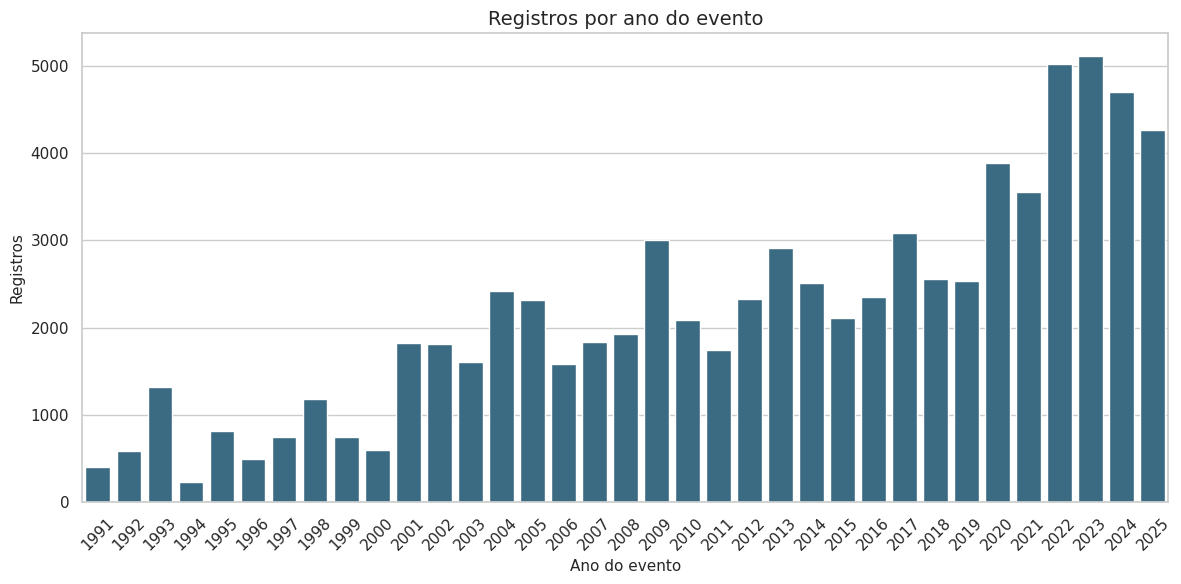

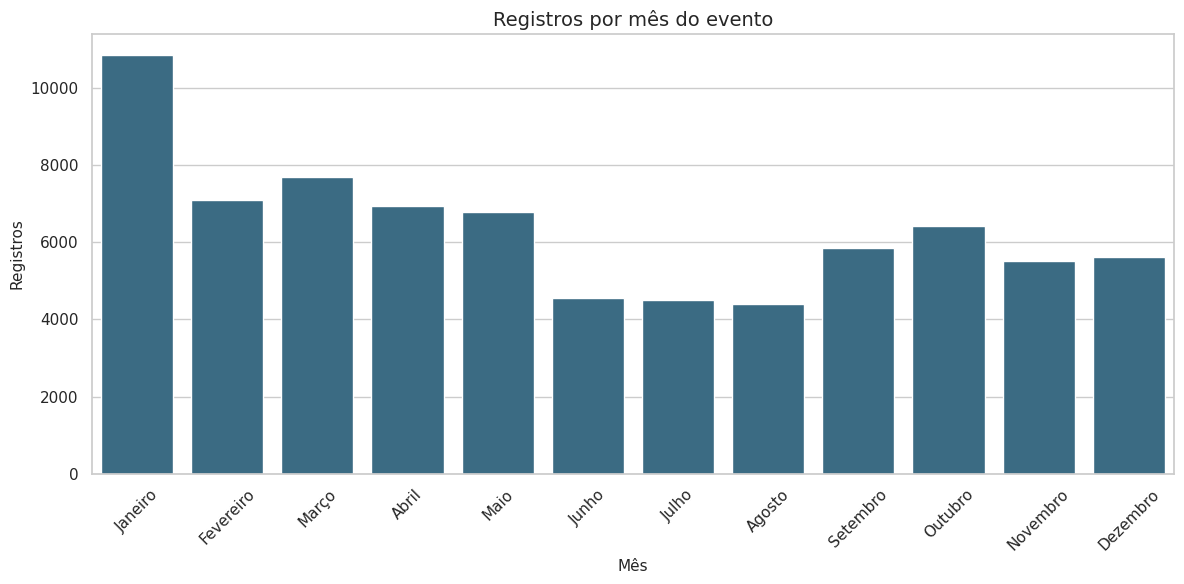

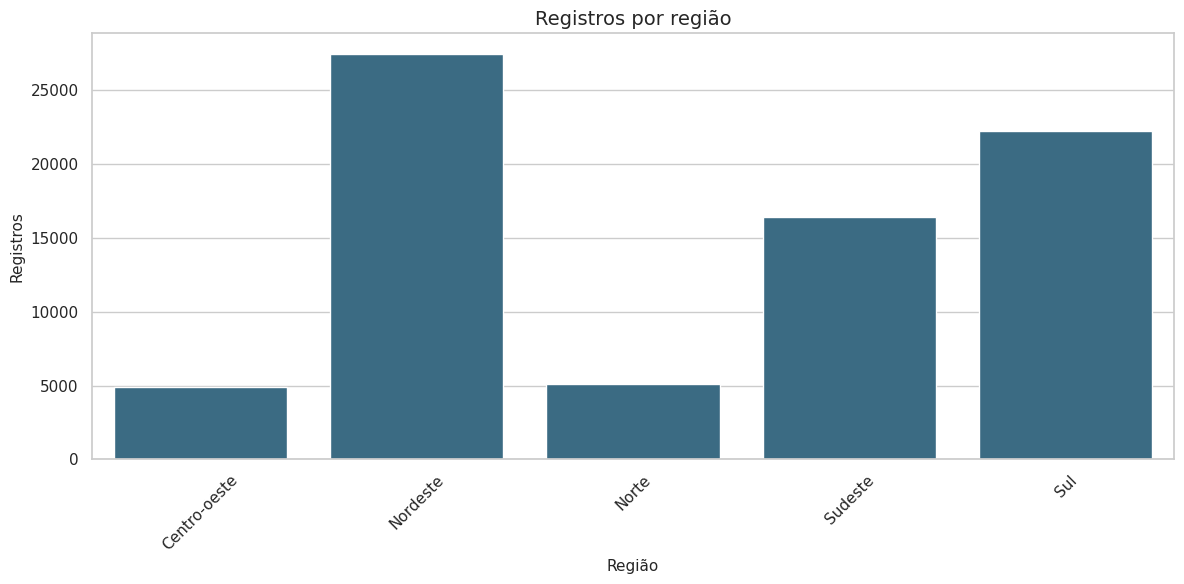

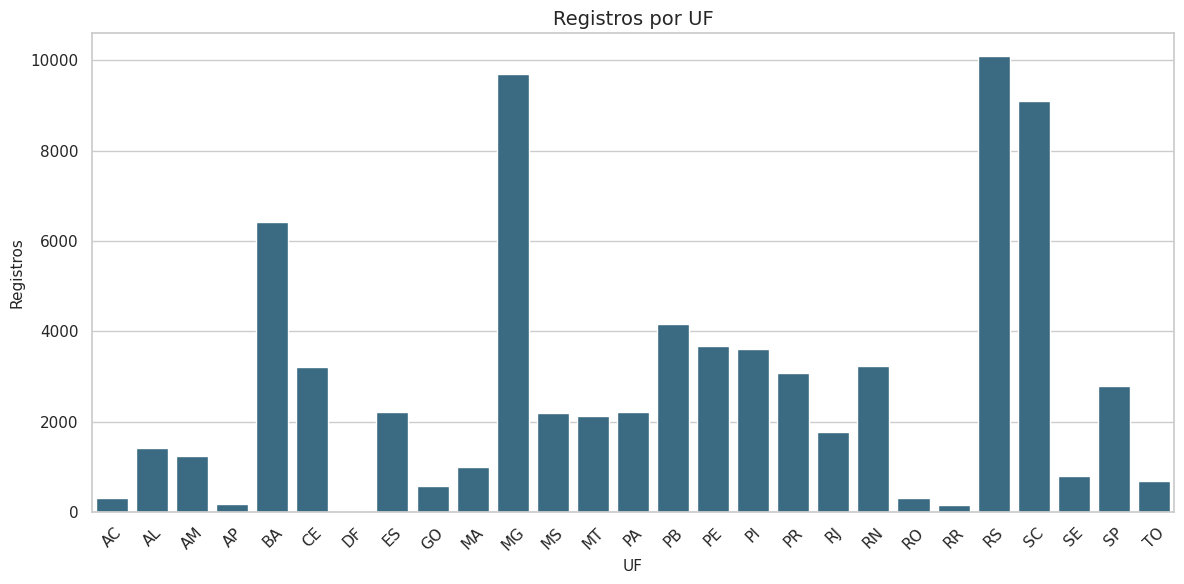

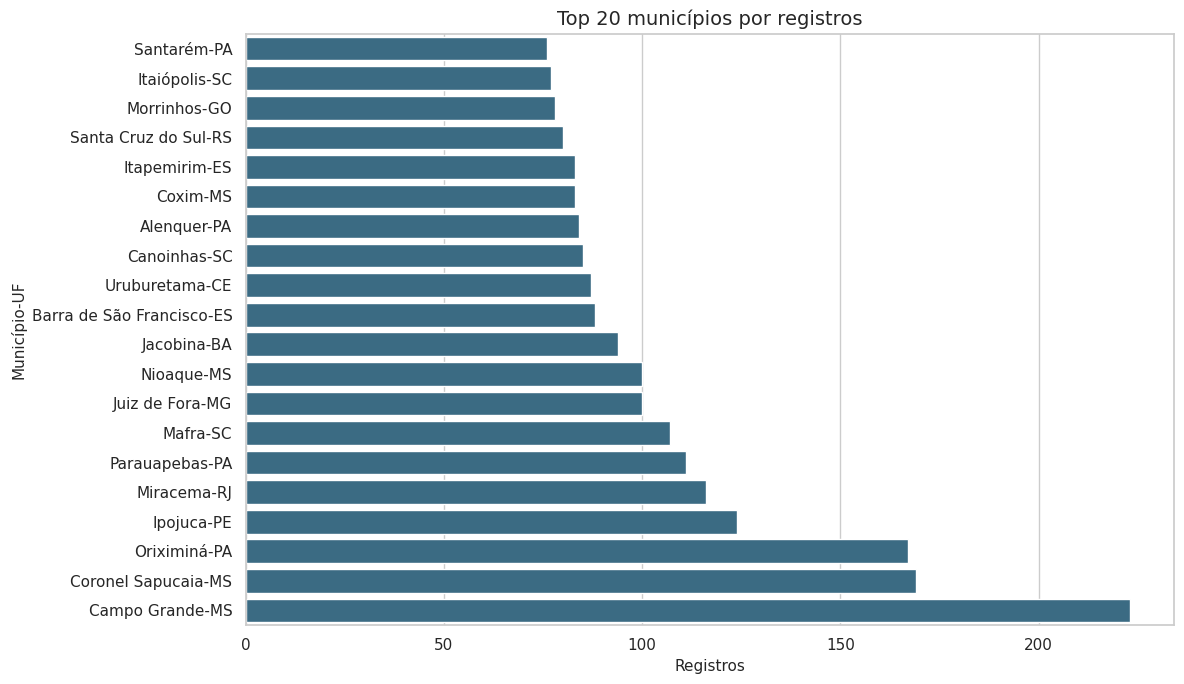

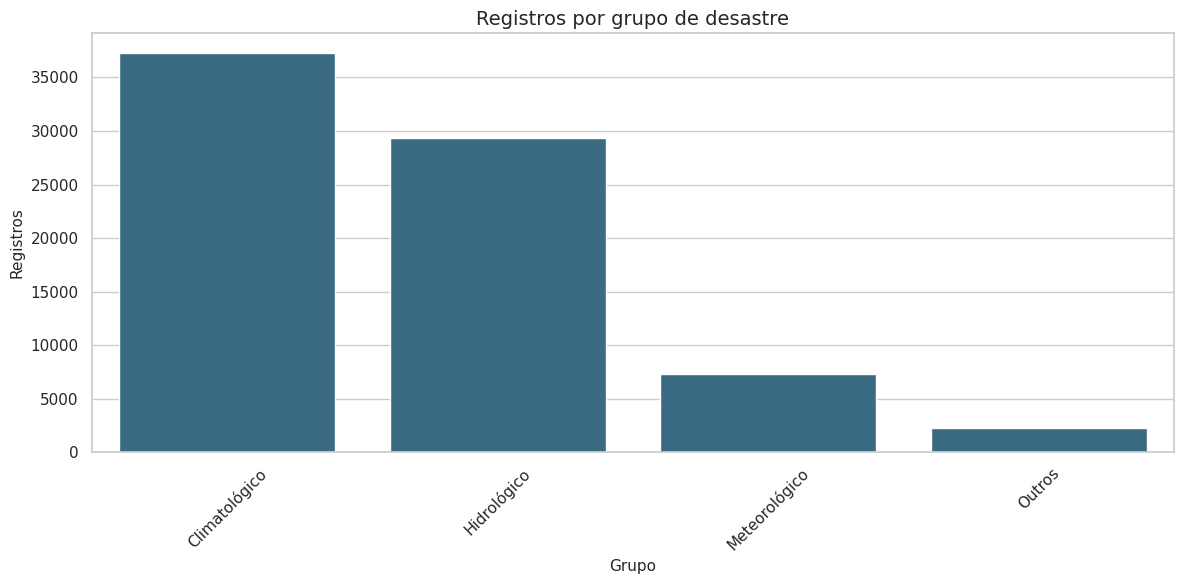

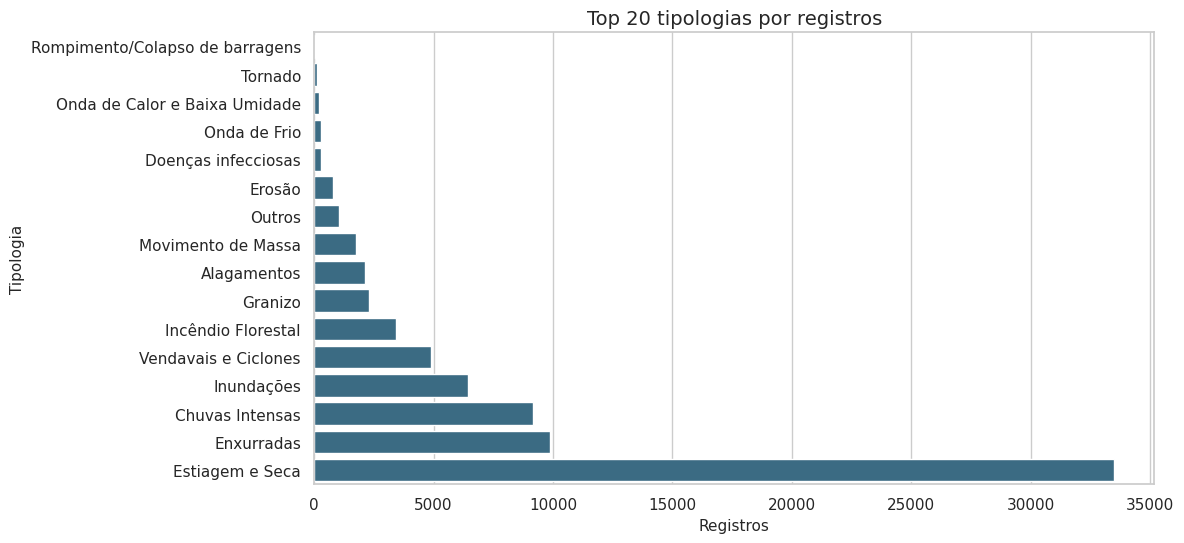

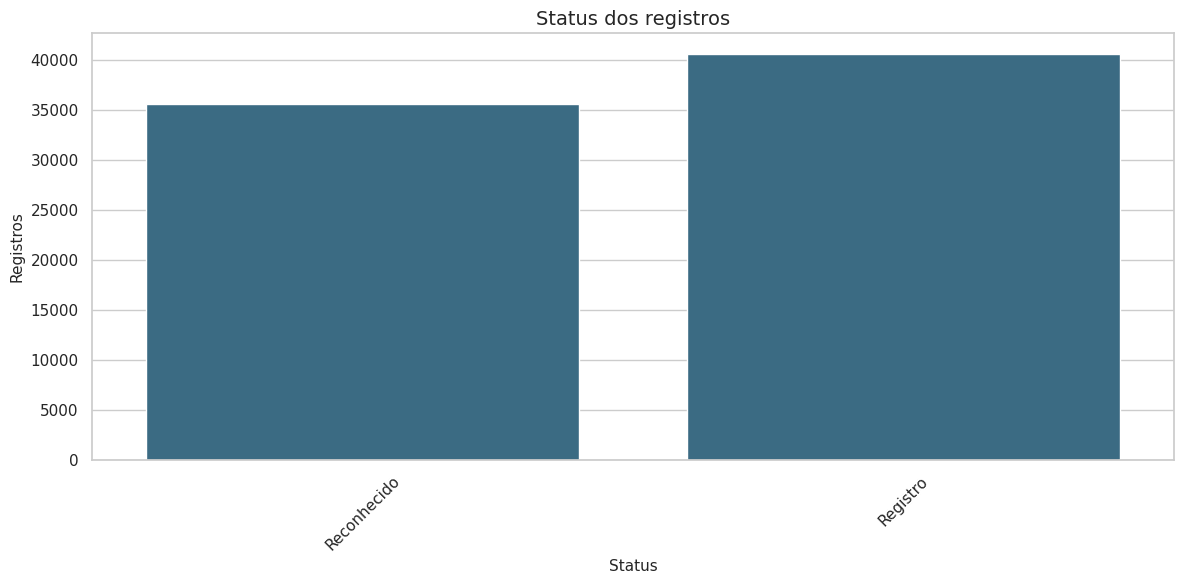

In [12]:
registros_ano = agg_count("ano_evento").dropna().sort_values("ano_evento")
registros_mes = agg_count("mes_nome")
registros_mes["mes_nome"] = pd.Categorical(
    registros_mes["mes_nome"], categories=MESES_ORDEM, ordered=True
)
registros_mes = registros_mes.sort_values("mes_nome")
registros_regiao = agg_count("regiao")
registros_uf = agg_count("Sigla_UF")
registros_municipio = agg_count("municipio_uf")
registros_grupo = agg_count("grupo_de_desastre")
registros_tipologia = agg_count("descricao_tipologia")
registros_status = agg_count("Status")

plot_bar(
    registros_ano,
    "ano_evento",
    "registros",
    "Registros por ano do evento",
    "Ano do evento",
    "Registros",
)
plot_bar(
    registros_mes,
    "mes_nome",
    "registros",
    "Registros por mês do evento",
    "Mês",
    "Registros",
)
plot_bar(
    registros_regiao,
    "regiao",
    "registros",
    "Registros por região",
    "Região",
    "Registros",
)
plot_bar(registros_uf, "Sigla_UF", "registros", "Registros por UF", "UF", "Registros")
plot_bar(
    registros_municipio,
    "municipio_uf",
    "registros",
    "Top 20 municípios por registros",
    "Registros",
    "Município-UF",
    horizontal=True,
    top=20,
)
plot_bar(
    registros_grupo,
    "grupo_de_desastre",
    "registros",
    "Registros por grupo de desastre",
    "Grupo",
    "Registros",
)
plot_bar(
    registros_tipologia,
    "descricao_tipologia",
    "registros",
    "Top 20 tipologias por registros",
    "Registros",
    "Tipologia",
    horizontal=True,
    top=20,
)
plot_bar(
    registros_status,
    "Status",
    "registros",
    "Status dos registros",
    "Status",
    "Registros",
)


In [14]:
ano_top = registros_ano.sort_values("registros", ascending=False).iloc[0]
uf_top = registros_uf.sort_values("registros", ascending=False).iloc[0]
tipologia_top = registros_tipologia.sort_values("registros", ascending=False).iloc[0]
grupo_top = registros_grupo.sort_values("registros", ascending=False).iloc[0]

display(
    Markdown(
        f"""
**Observações**

- O ano com maior concentração de registros é **{int(ano_top["ano_evento"])}**, com **{int(ano_top["registros"]):,}** registros.
- A UF mais recorrente é **{uf_top["Sigla_UF"]}**, com **{int(uf_top["registros"]):,}** registros.
- A tipologia dominante é **{tipologia_top["descricao_tipologia"]}**, com **{int(tipologia_top["registros"]):,}** registros.
- O grupo de desastre mais frequente é **{grupo_top["grupo_de_desastre"]}**, com **{int(grupo_top["registros"]):,}** registros.
- Ideal filtros rápidos por ano, UF, grupo e tipologia.
""".replace(",", ".")
    )
)



**Observações**

- O ano com maior concentração de registros é **2023**. com **5.115** registros.
- A UF mais recorrente é **RS**. com **10.091** registros.
- A tipologia dominante é **Estiagem e Seca**. com **33.493** registros.
- O grupo de desastre mais frequente é **Climatológico**. com **37.260** registros.
- Ideal filtros rápidos por ano. UF. grupo e tipologia.


## 9. Análise por região, UF e município

Esta seção destaca a distribuição territorial dos registros e cruza UF com grupo de desastre para revelar diferenças regionais úteis ao dashboard.

,regiao,Sigla_UF,registros
25,Sul,RS,10091
21,Sudeste,MG,9686
26,Sul,SC,9108
5,Nordeste,BA,6421
8,Nordeste,PB,4150
9,Nordeste,PE,3678
10,Nordeste,PI,3603
11,Nordeste,RN,3227
6,Nordeste,CE,3205
24,Sul,PR,3070


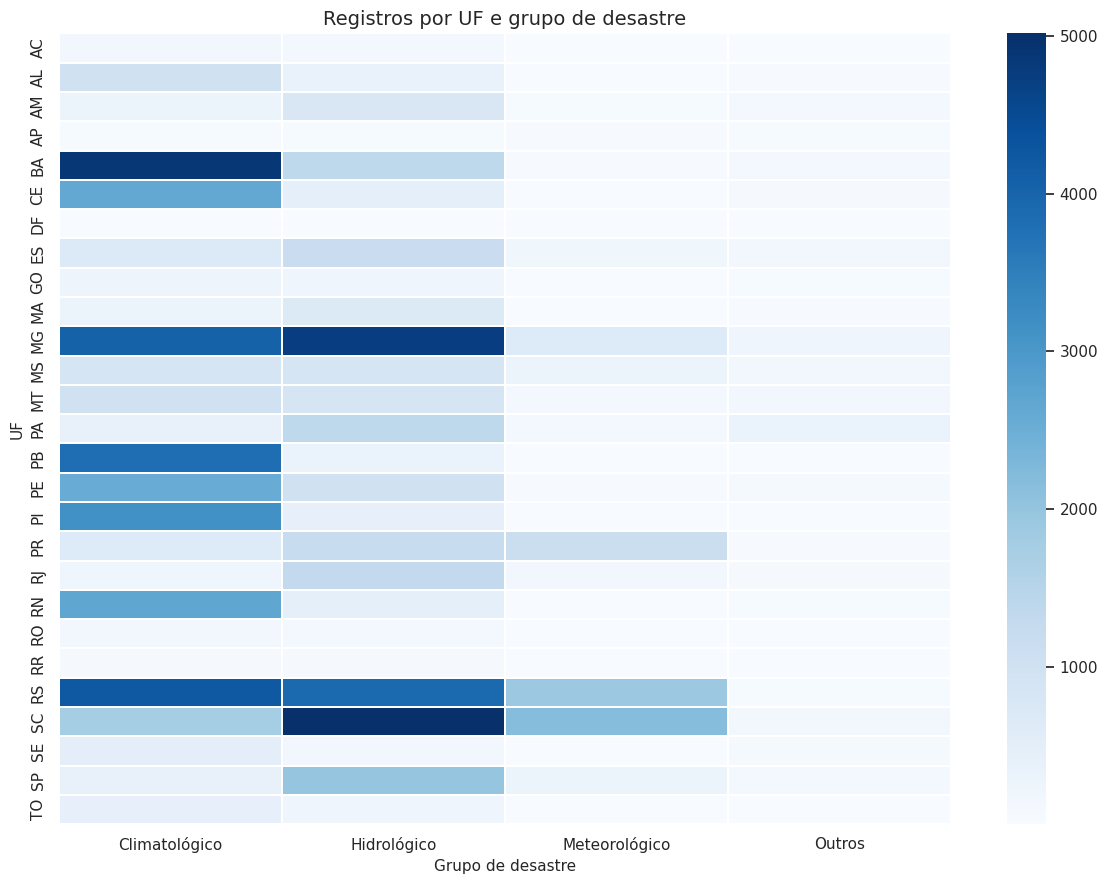

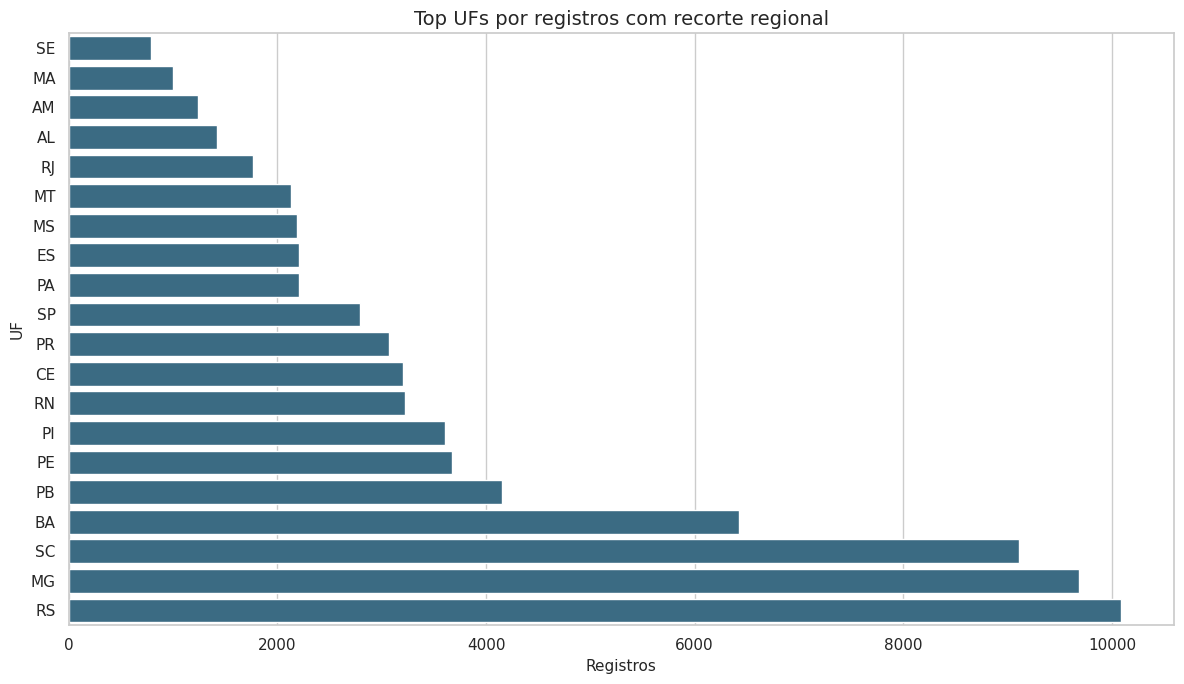

In [15]:
regiao_uf = (
    df_analitico.groupby(["regiao", "Sigla_UF"], observed=True)
    .size()
    .reset_index(name="registros")
    .sort_values("registros", ascending=False)
)
display(regiao_uf)

uf_grupo = df_analitico.pivot_table(
    index="Sigla_UF",
    columns="grupo_de_desastre",
    values="Protocolo_S2iD",
    aggfunc="count",
    fill_value=0,
    observed=True,
)
fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(uf_grupo, cmap="Blues", linewidths=0.2, ax=ax)
ax.set_title("Registros por UF e grupo de desastre")
ax.set_xlabel("Grupo de desastre")
ax.set_ylabel("UF")
plt.tight_layout()
plt.show()
plt.close(fig)

plot_bar(
    regiao_uf,
    "Sigla_UF",
    "registros",
    "Top UFs por registros com recorte regional",
    "Registros",
    "UF",
    horizontal=True,
    top=20,
)


## 10. Análise de danos humanos

Os danos humanos são analisados por KPIs e rankings temporais, territoriais e por tipo de desastre. Feridos e enfermos são consolidados, assim como desabrigados e desalojados.

,métrica,valor
0,Óbitos,5535
1,Feridos + enfermos,1833805
2,Desabrigados + desalojados,11179882
3,Afetados diretos,144459020
4,Desaparecidos,3116


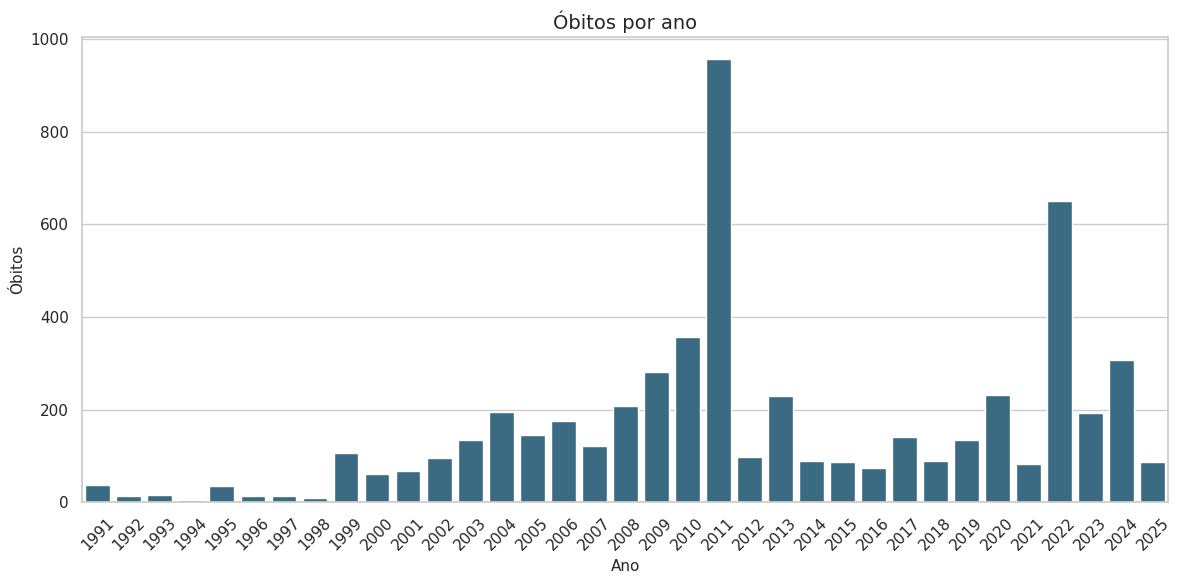

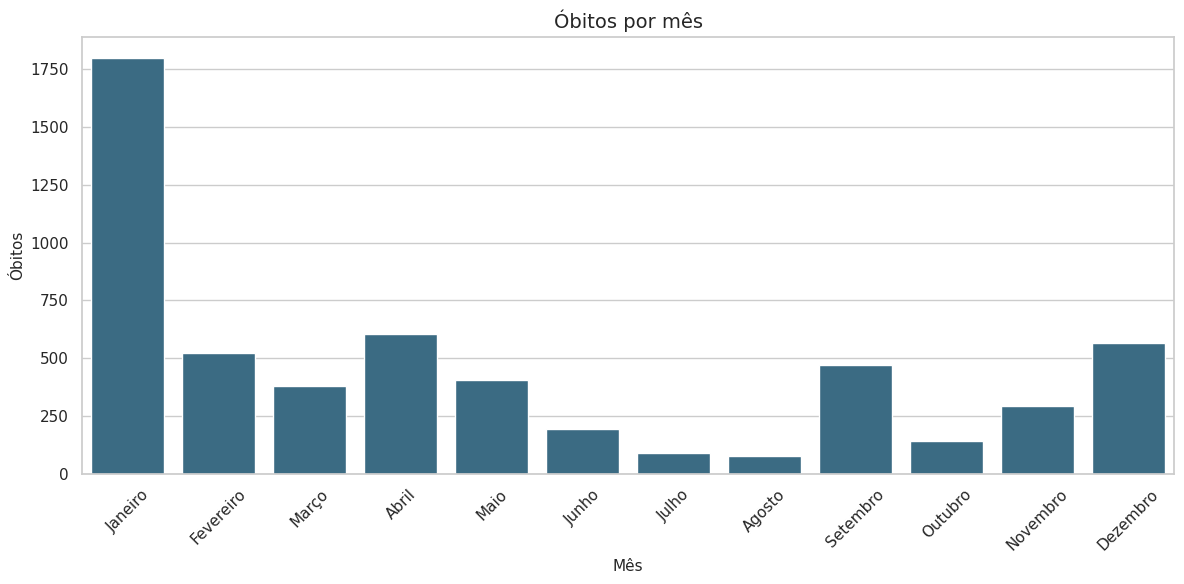

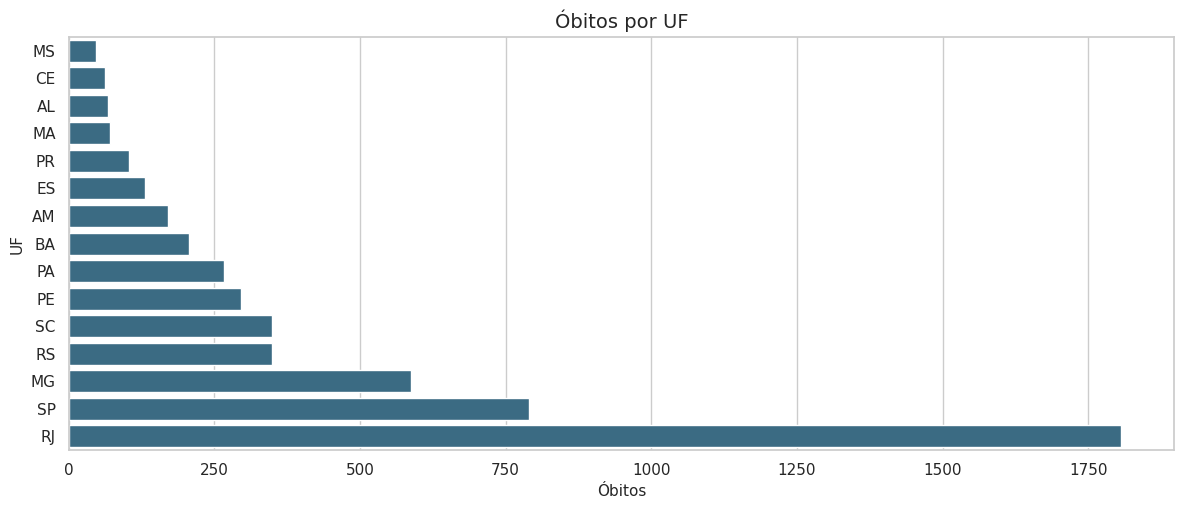

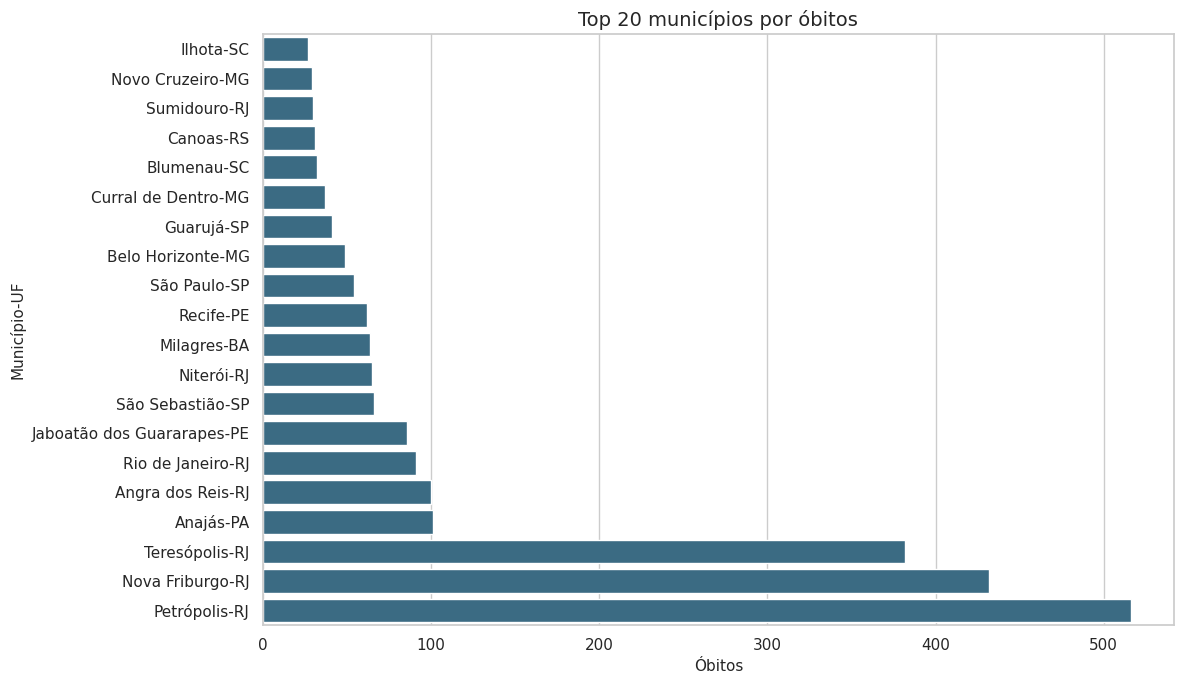

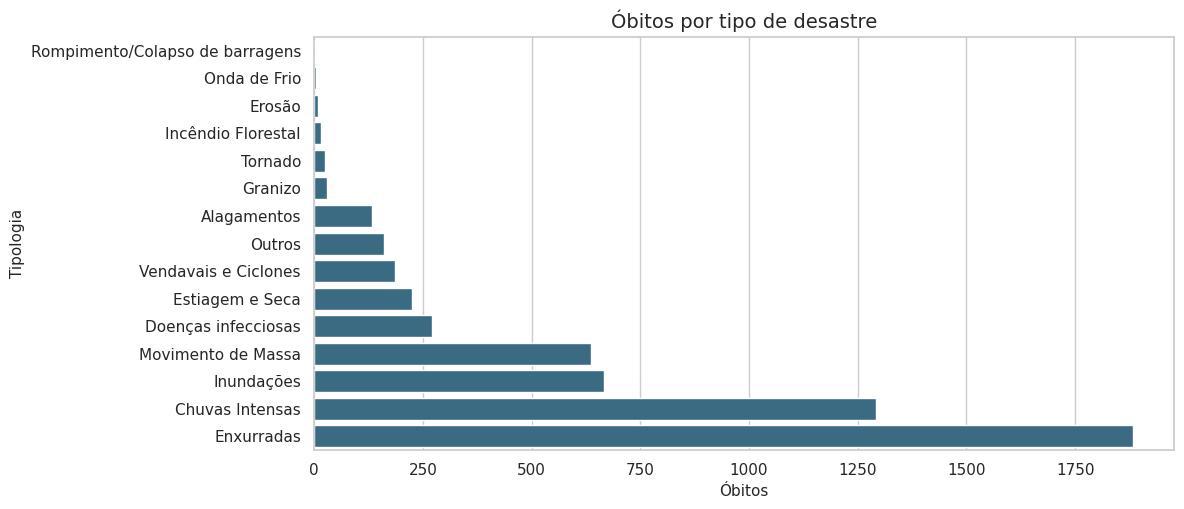

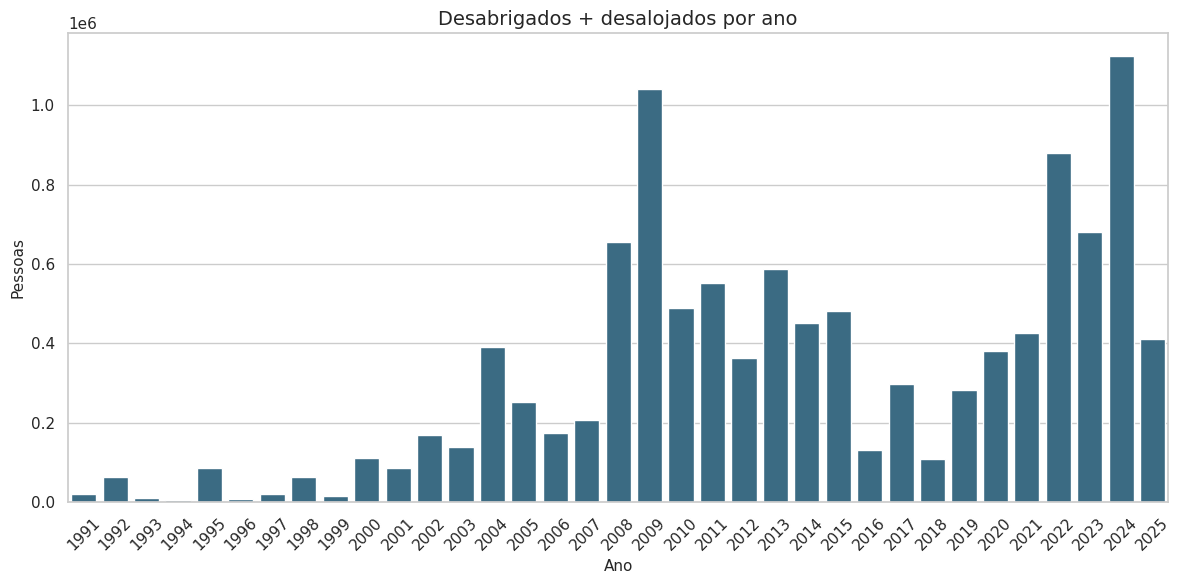

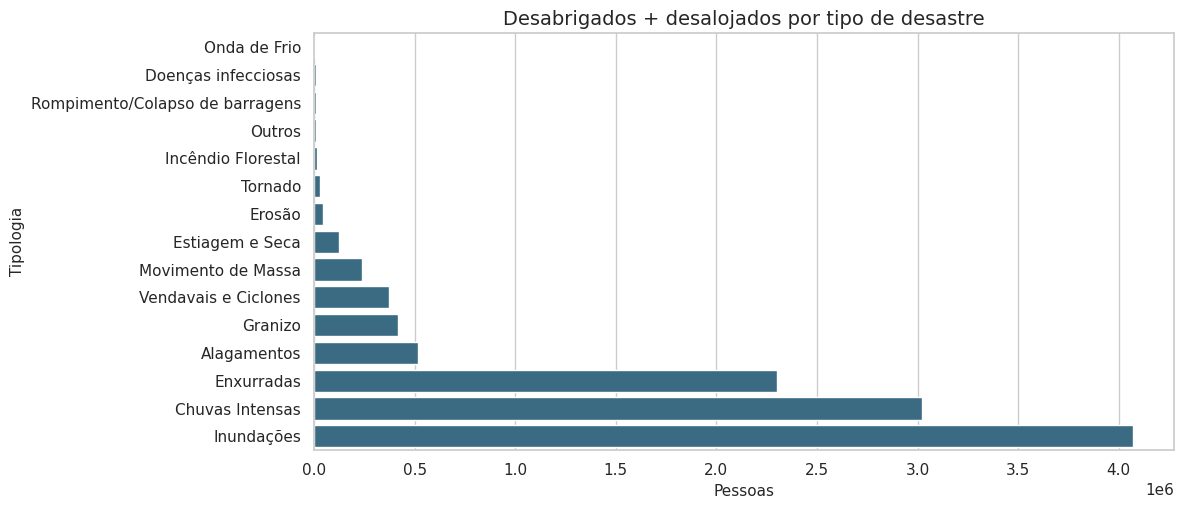

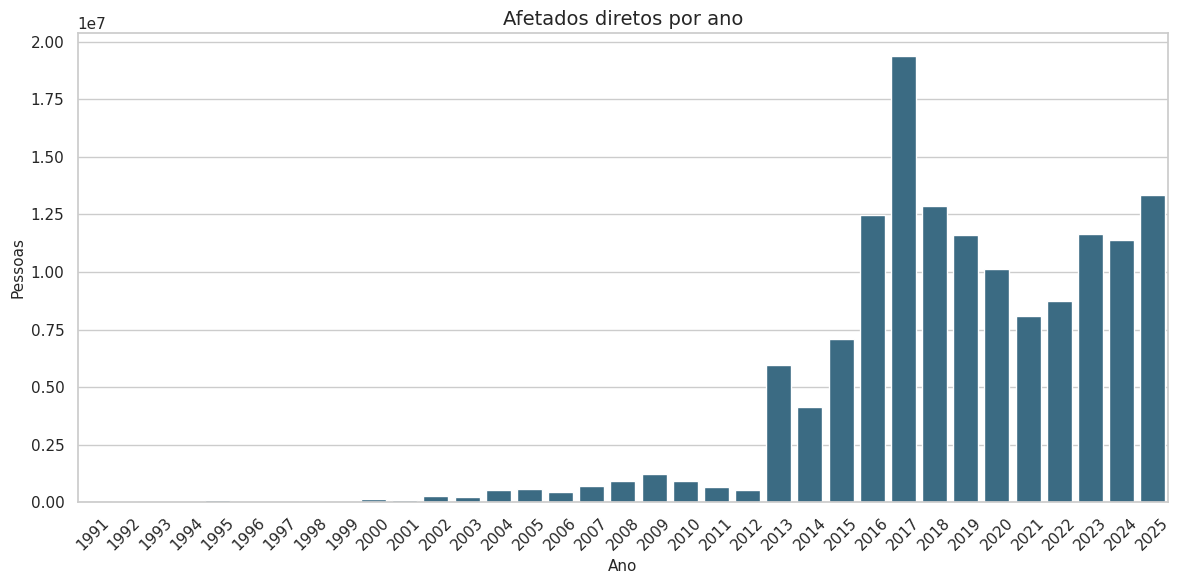

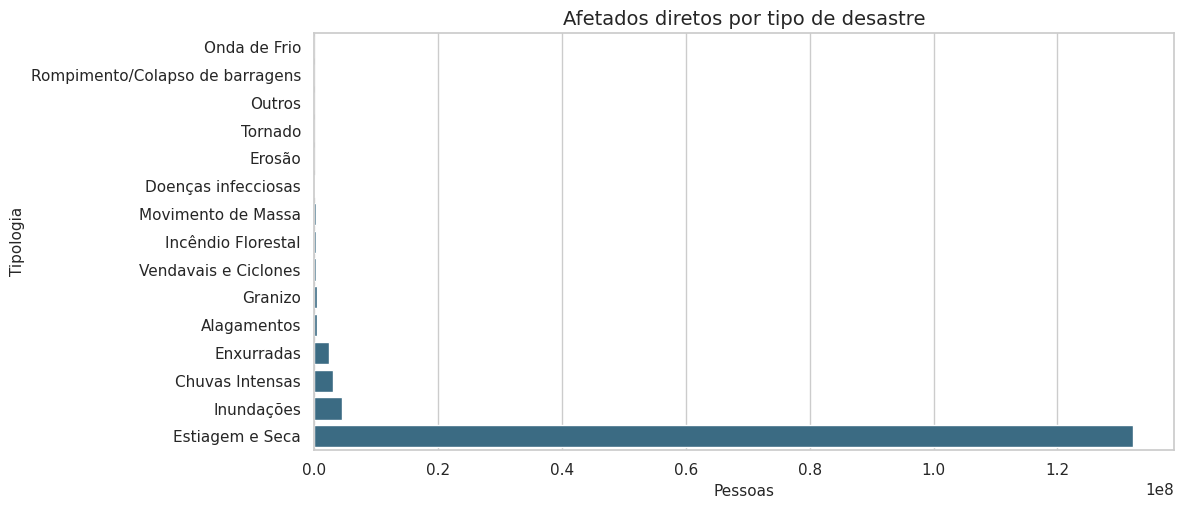

In [16]:
kpis_humanos = pd.DataFrame(
    {
        "métrica": [
            "Óbitos",
            "Feridos + enfermos",
            "Desabrigados + desalojados",
            "Afetados diretos",
            "Desaparecidos",
        ],
        "valor": [
            df_analitico["DH_MORTOS"].sum(),
            df_analitico["feridos_enfermos"].sum(),
            df_analitico["desabrigados_desalojados"].sum(),
            df_analitico["DH_total_danos_humanos_diretos"].sum(),
            df_analitico["DH_DESAPARECIDOS"].sum(),
        ],
    }
)
display(kpis_humanos)

obitos_ano = (
    agg_sum("ano_evento", "DH_MORTOS", "obitos").dropna().sort_values("ano_evento")
)
obitos_mes = agg_sum("mes_nome", "DH_MORTOS", "obitos")
obitos_mes["mes_nome"] = pd.Categorical(
    obitos_mes["mes_nome"], categories=MESES_ORDEM, ordered=True
)
obitos_mes = obitos_mes.sort_values("mes_nome")
obitos_uf = agg_sum("Sigla_UF", "DH_MORTOS", "obitos")
obitos_municipio = agg_sum("municipio_uf", "DH_MORTOS", "obitos")
obitos_tipo = agg_sum("descricao_tipologia", "DH_MORTOS", "obitos")
desalojados_ano = (
    agg_sum("ano_evento", "desabrigados_desalojados", "desabrigados_desalojados")
    .dropna()
    .sort_values("ano_evento")
)
desalojados_tipo = agg_sum(
    "descricao_tipologia", "desabrigados_desalojados", "desabrigados_desalojados"
)
afetados_ano = (
    agg_sum("ano_evento", "DH_total_danos_humanos_diretos", "afetados")
    .dropna()
    .sort_values("ano_evento")
)
afetados_tipo = agg_sum(
    "descricao_tipologia", "DH_total_danos_humanos_diretos", "afetados"
)

plot_bar(obitos_ano, "ano_evento", "obitos", "Óbitos por ano", "Ano", "Óbitos")
plot_bar(obitos_mes, "mes_nome", "obitos", "Óbitos por mês", "Mês", "Óbitos")
plot_bar(
    obitos_uf,
    "Sigla_UF",
    "obitos",
    "Óbitos por UF",
    "Óbitos",
    "UF",
    horizontal=True,
    top=15,
)
plot_bar(
    obitos_municipio,
    "municipio_uf",
    "obitos",
    "Top 20 municípios por óbitos",
    "Óbitos",
    "Município-UF",
    horizontal=True,
    top=20,
)
plot_bar(
    obitos_tipo,
    "descricao_tipologia",
    "obitos",
    "Óbitos por tipo de desastre",
    "Óbitos",
    "Tipologia",
    horizontal=True,
    top=15,
)
plot_bar(
    desalojados_ano,
    "ano_evento",
    "desabrigados_desalojados",
    "Desabrigados + desalojados por ano",
    "Ano",
    "Pessoas",
)
plot_bar(
    desalojados_tipo,
    "descricao_tipologia",
    "desabrigados_desalojados",
    "Desabrigados + desalojados por tipo de desastre",
    "Pessoas",
    "Tipologia",
    horizontal=True,
    top=15,
)
plot_bar(
    afetados_ano, "ano_evento", "afetados", "Afetados diretos por ano", "Ano", "Pessoas"
)
plot_bar(
    afetados_tipo,
    "descricao_tipologia",
    "afetados",
    "Afetados diretos por tipo de desastre",
    "Pessoas",
    "Tipologia",
    horizontal=True,
    top=15,
)


In [18]:
obito_ano_top = obitos_ano.sort_values("obitos", ascending=False).iloc[0]
obito_uf_top = obitos_uf.sort_values("obitos", ascending=False).iloc[0]
afetados_tipo_top = afetados_tipo.sort_values("afetados", ascending=False).iloc[0]

display(
    Markdown(
        f"""
**Observações**

- O ano mais crítico em óbitos é **{int(obito_ano_top["ano_evento"])}**, com **{int(obito_ano_top["obitos"]):,}** óbitos registrados.
- A UF com maior soma de óbitos é **{obito_uf_top["Sigla_UF"]}**, com **{int(obito_uf_top["obitos"]):,}** óbitos.
- A tipologia com mais afetados diretos é **{afetados_tipo_top["descricao_tipologia"]}**, com **{int(afetados_tipo_top["afetados"]):,}** pessoas.
""".replace(",", ".")
    )
)



**Observações**

- O ano mais crítico em óbitos é **2011**. com **957** óbitos registrados.
- A UF com maior soma de óbitos é **RJ**. com **1.807** óbitos.
- A tipologia com mais afetados diretos é **Estiagem e Seca**. com **132.202.814** pessoas.


## 11. Análise de danos materiais

Os danos materiais usam os valores corrigidos do Atlas. As visualizações priorizam totais por ano, mês, UF, município, categoria e tipologia.

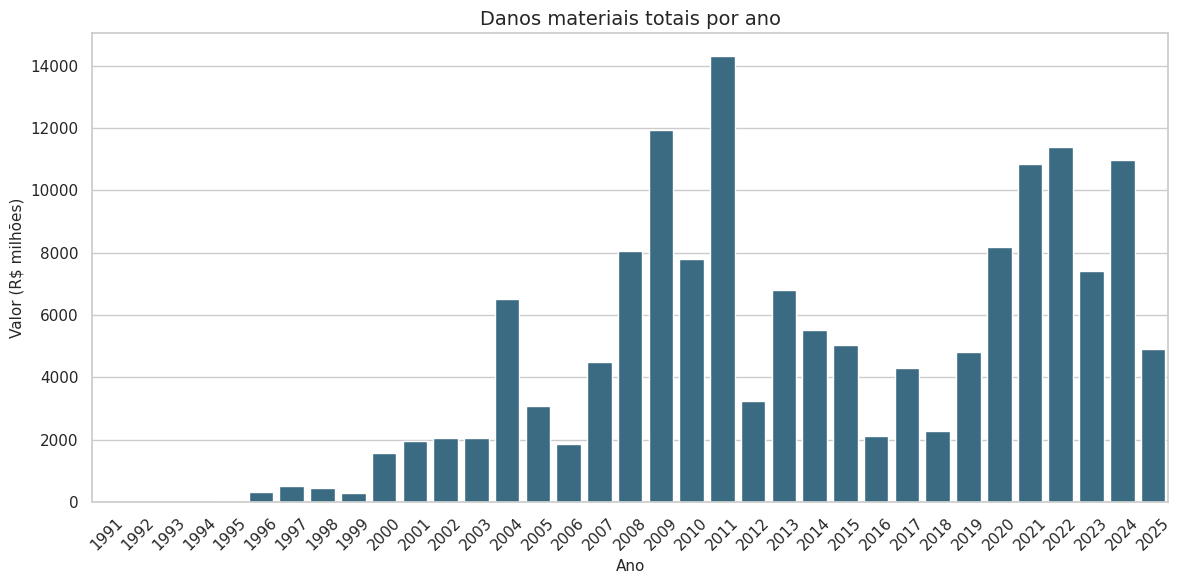

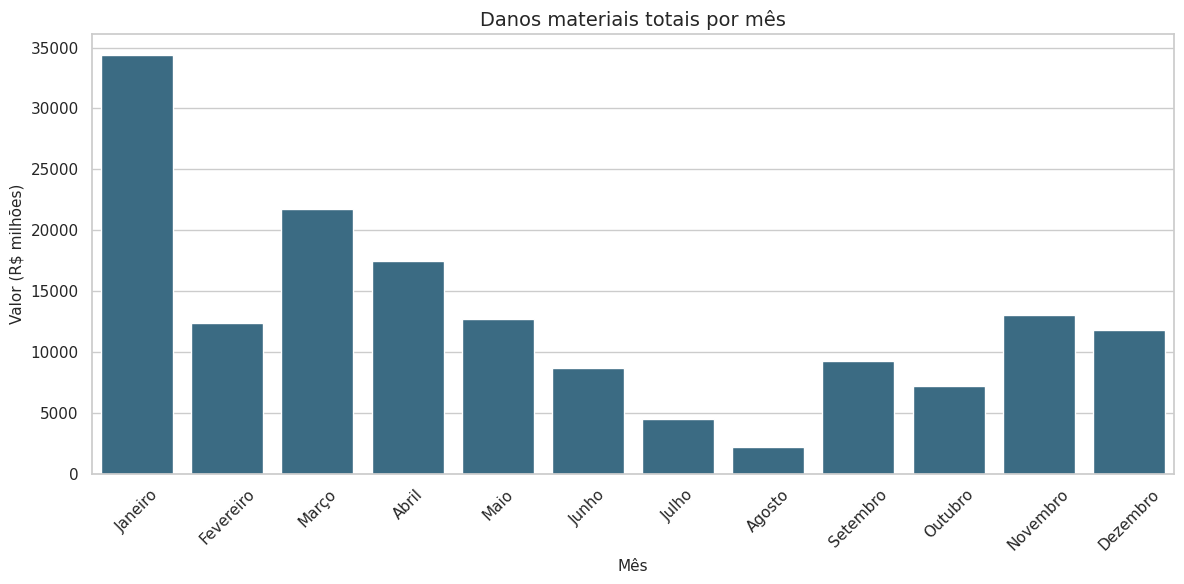

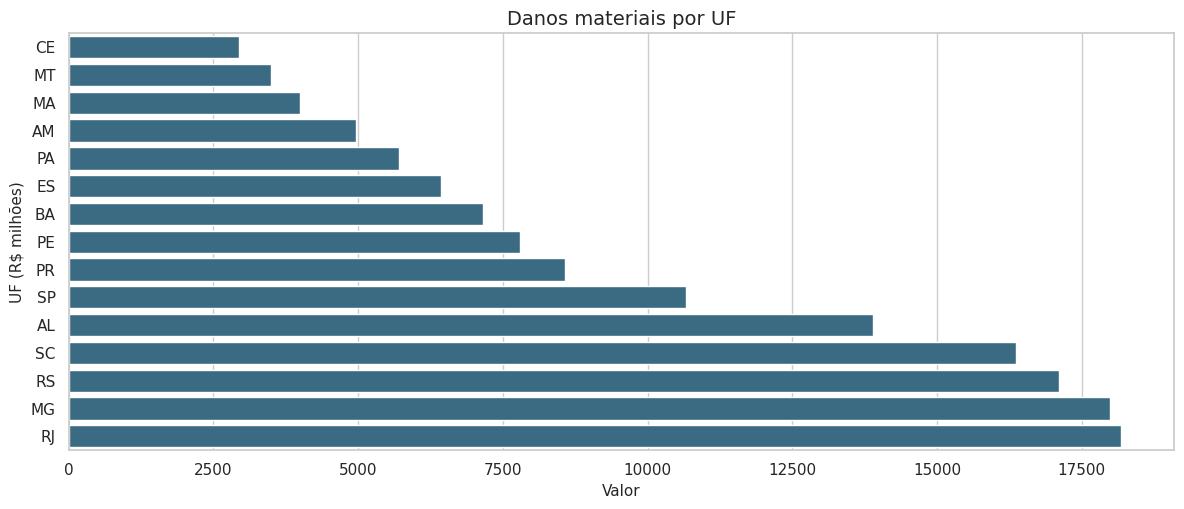

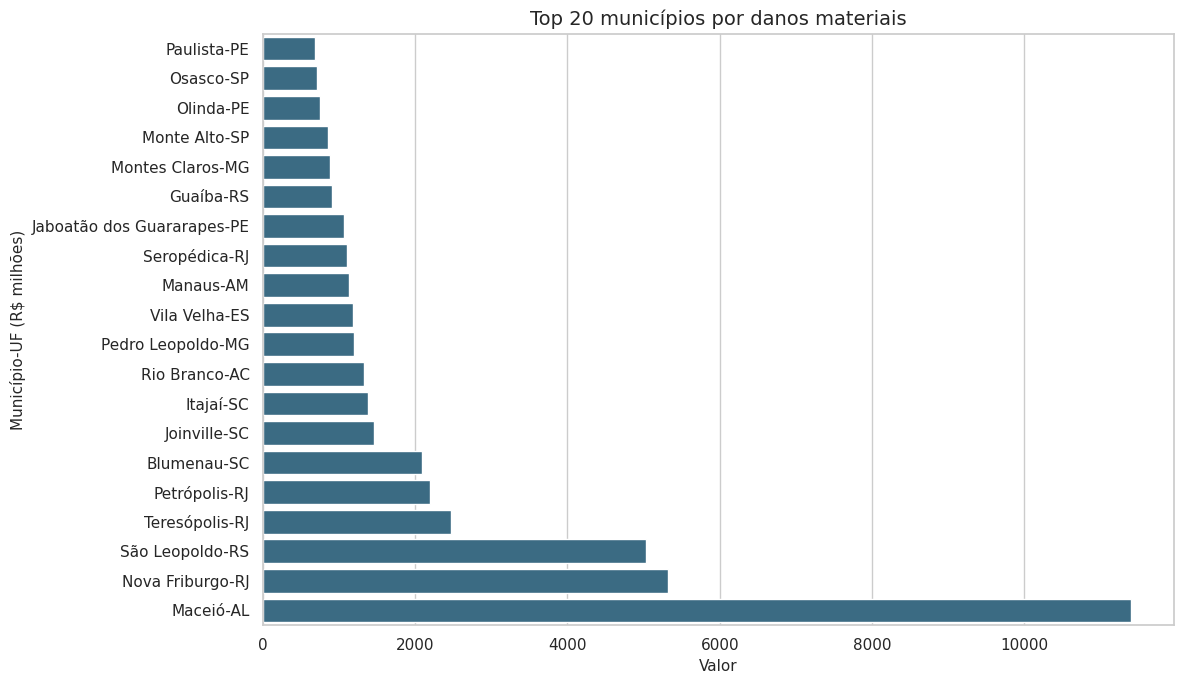

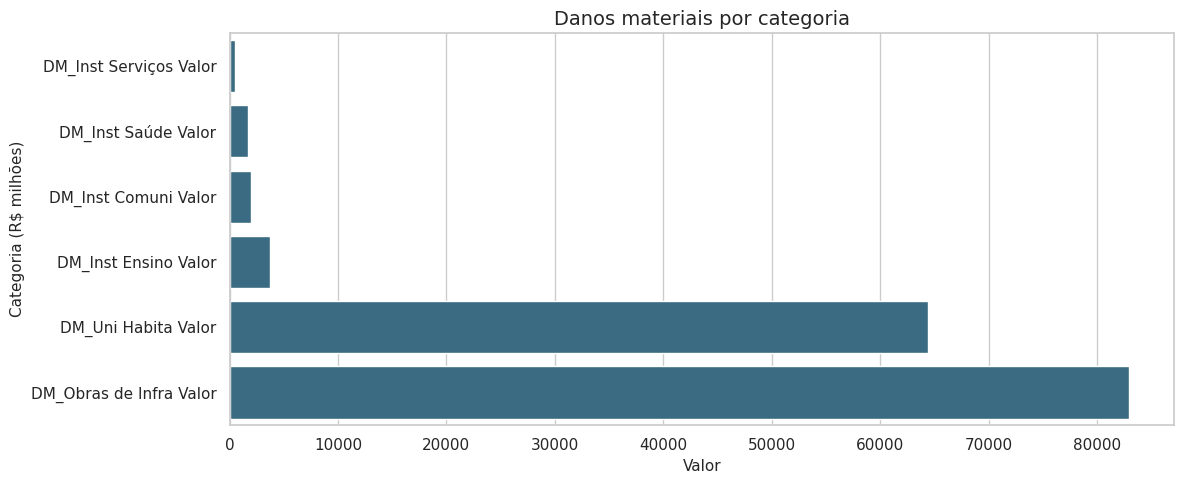

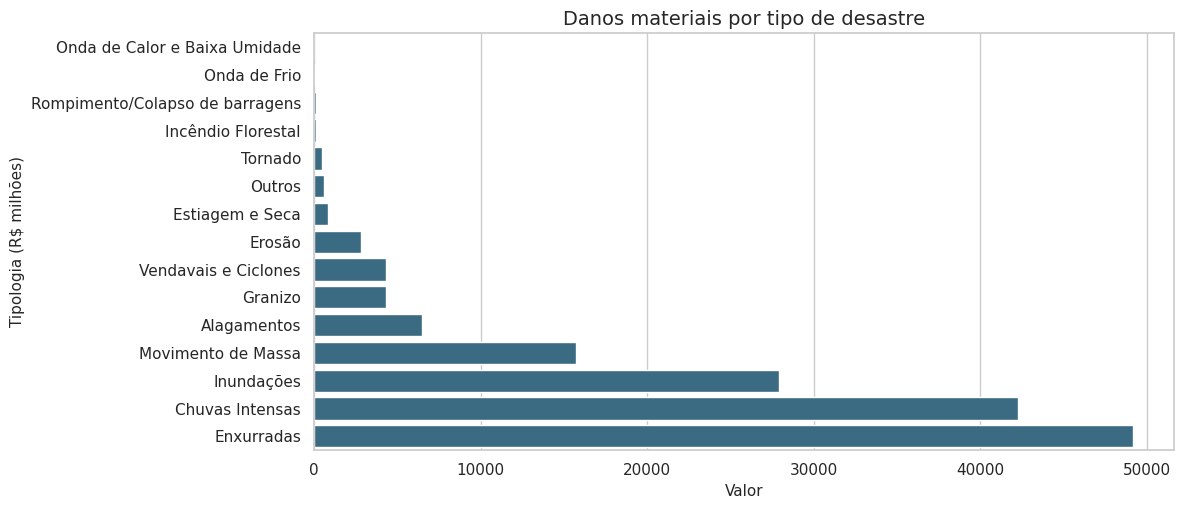

In [19]:
danos_ano = (
    agg_sum("ano_evento", "DM_total_danos_materiais", "danos_materiais")
    .dropna()
    .sort_values("ano_evento")
)
danos_mes = agg_sum("mes_nome", "DM_total_danos_materiais", "danos_materiais")
danos_mes["mes_nome"] = pd.Categorical(
    danos_mes["mes_nome"], categories=MESES_ORDEM, ordered=True
)
danos_mes = danos_mes.sort_values("mes_nome")
danos_uf = agg_sum("Sigla_UF", "DM_total_danos_materiais", "danos_materiais")
danos_municipio = agg_sum("municipio_uf", "DM_total_danos_materiais", "danos_materiais")
danos_tipo = agg_sum(
    "descricao_tipologia", "DM_total_danos_materiais", "danos_materiais"
)
danos_categoria = (
    df_danos_materiais_long.groupby("categoria_dano_material", observed=True)["valor"]
    .sum()
    .reset_index(name="danos_materiais")
)

plot_bar(
    danos_ano,
    "ano_evento",
    "danos_materiais",
    "Danos materiais totais por ano",
    "Ano",
    "Valor",
    money=True,
)
plot_bar(
    danos_mes,
    "mes_nome",
    "danos_materiais",
    "Danos materiais totais por mês",
    "Mês",
    "Valor",
    money=True,
)
plot_bar(
    danos_uf,
    "Sigla_UF",
    "danos_materiais",
    "Danos materiais por UF",
    "Valor",
    "UF",
    horizontal=True,
    top=15,
    money=True,
)
plot_bar(
    danos_municipio,
    "municipio_uf",
    "danos_materiais",
    "Top 20 municípios por danos materiais",
    "Valor",
    "Município-UF",
    horizontal=True,
    top=20,
    money=True,
)
plot_bar(
    danos_categoria,
    "categoria_dano_material",
    "danos_materiais",
    "Danos materiais por categoria",
    "Valor",
    "Categoria",
    horizontal=True,
    money=True,
)
plot_bar(
    danos_tipo,
    "descricao_tipologia",
    "danos_materiais",
    "Danos materiais por tipo de desastre",
    "Valor",
    "Tipologia",
    horizontal=True,
    top=15,
    money=True,
)


In [21]:
danos_ano_top = danos_ano.sort_values("danos_materiais", ascending=False).iloc[0]
danos_uf_top = danos_uf.sort_values("danos_materiais", ascending=False).iloc[0]
danos_categoria_top = danos_categoria.sort_values(
    "danos_materiais", ascending=False
).iloc[0]

display(
    Markdown(f"""
**Observações**

- O maior total anual de danos materiais ocorre em **{int(danos_ano_top["ano_evento"])}**, com **{dinheiro(danos_ano_top["danos_materiais"])}**.
- A UF de maior destaque em danos materiais é **{danos_uf_top["Sigla_UF"]}**, com **{dinheiro(danos_uf_top["danos_materiais"])}**.
- A categoria que mais concentra valores é **{danos_categoria_top["categoria_dano_material"]}**, com **{dinheiro(danos_categoria_top["danos_materiais"])}**.

""")
)



**Observações**

- O maior total anual de danos materiais ocorre em **2011**, com **R$ 14.32 bi**.
- A UF de maior destaque em danos materiais é **RJ**, com **R$ 18.19 bi**.
- A categoria que mais concentra valores é **DM_Obras de Infra Valor**, com **R$ 82.94 bi**.



## 12. Análise de prejuízos públicos e privados

Esta seção separa perdas públicas, associadas a serviços essenciais, e perdas privadas, associadas a setores econômicos. Ambas usam valores corrigidos.

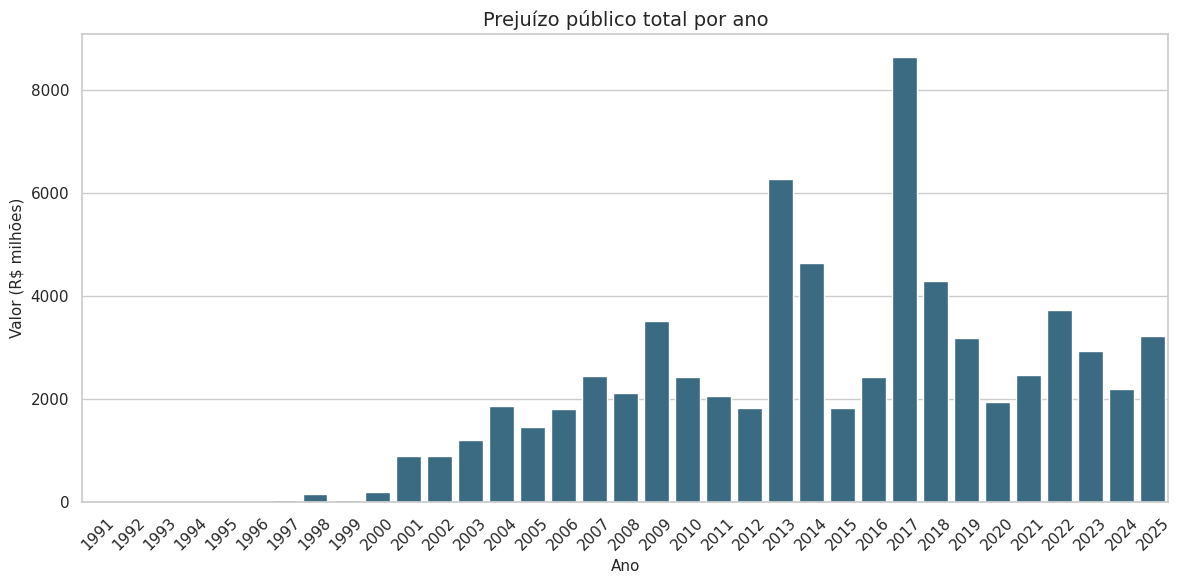

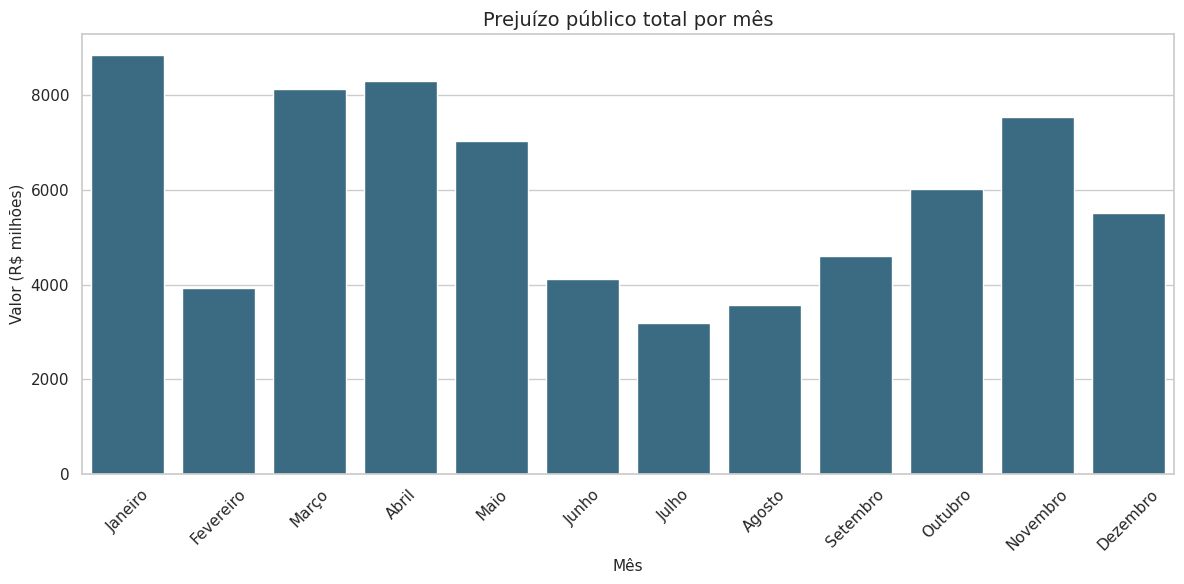

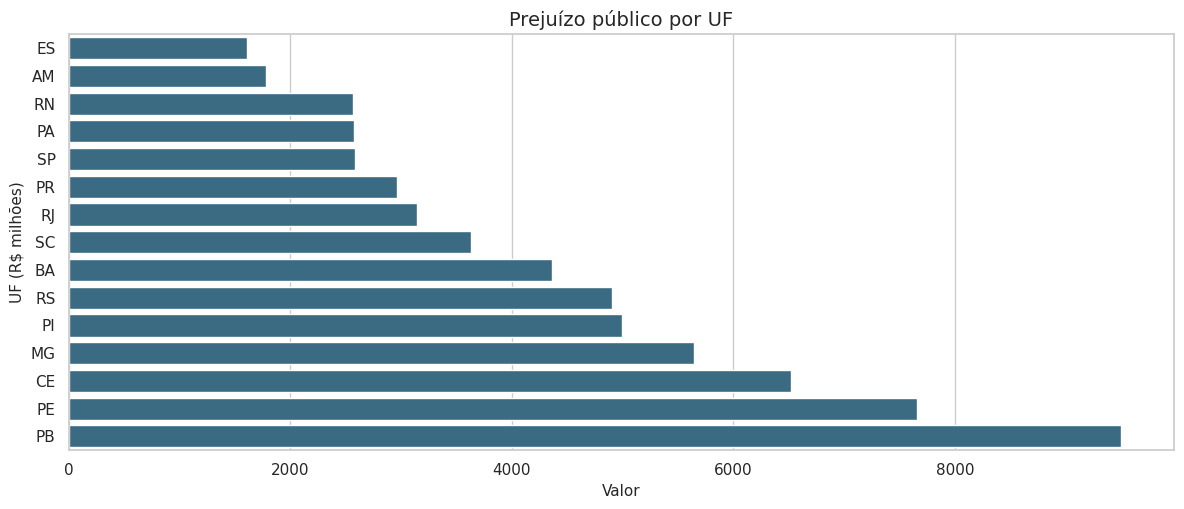

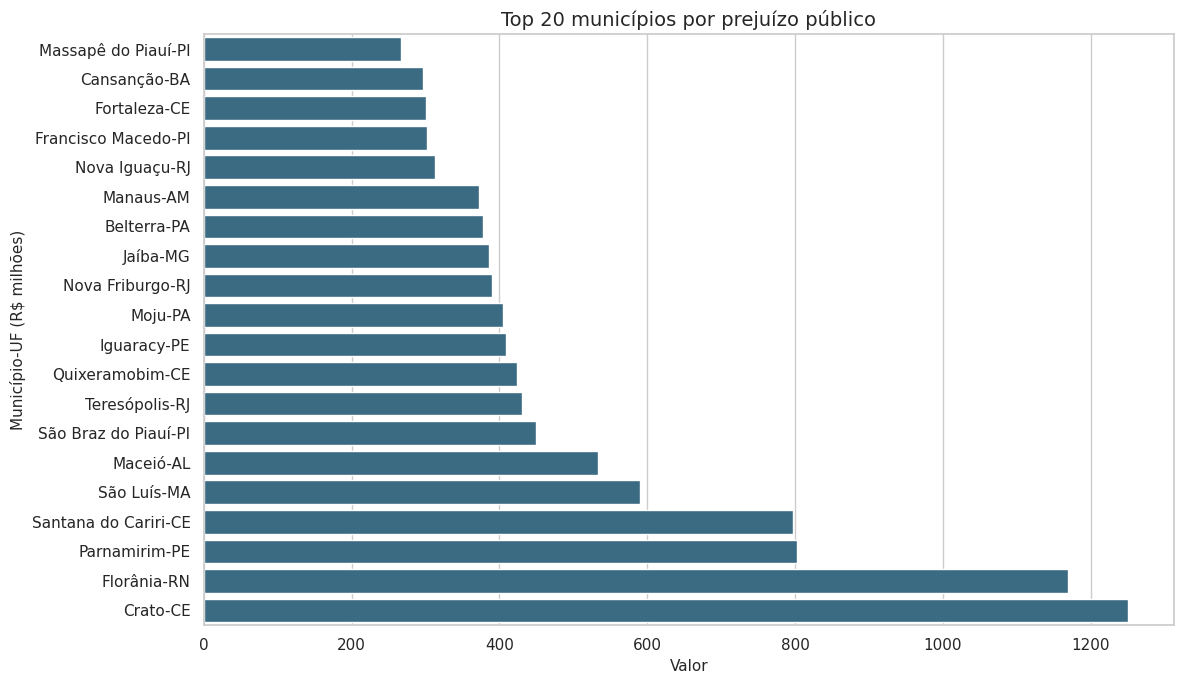

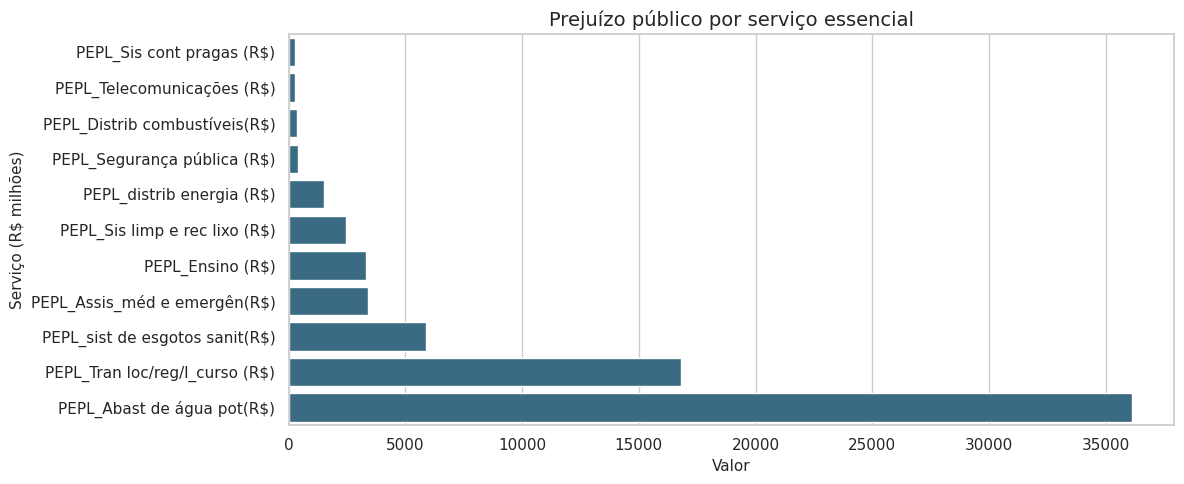

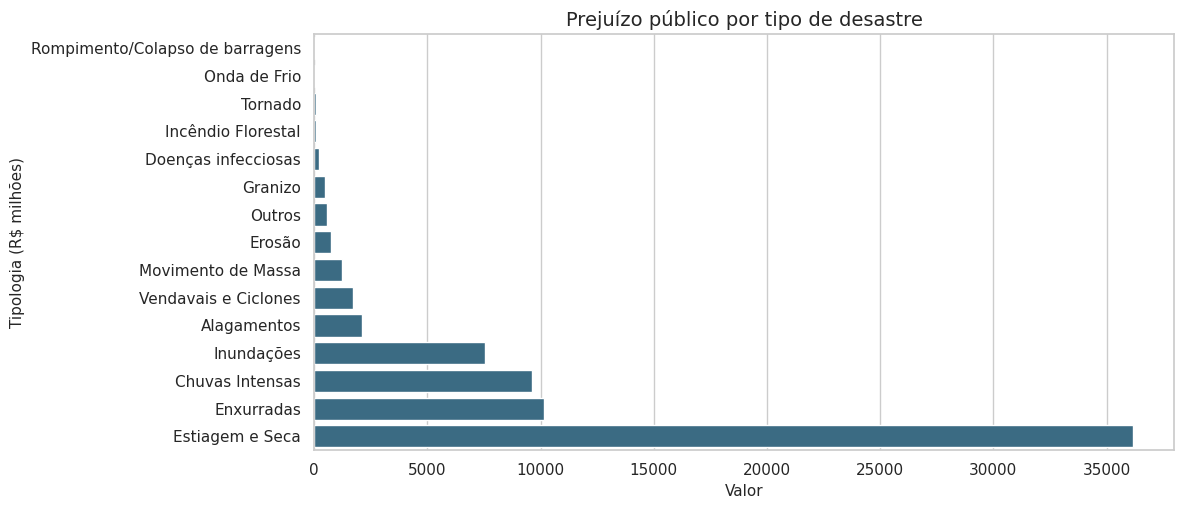

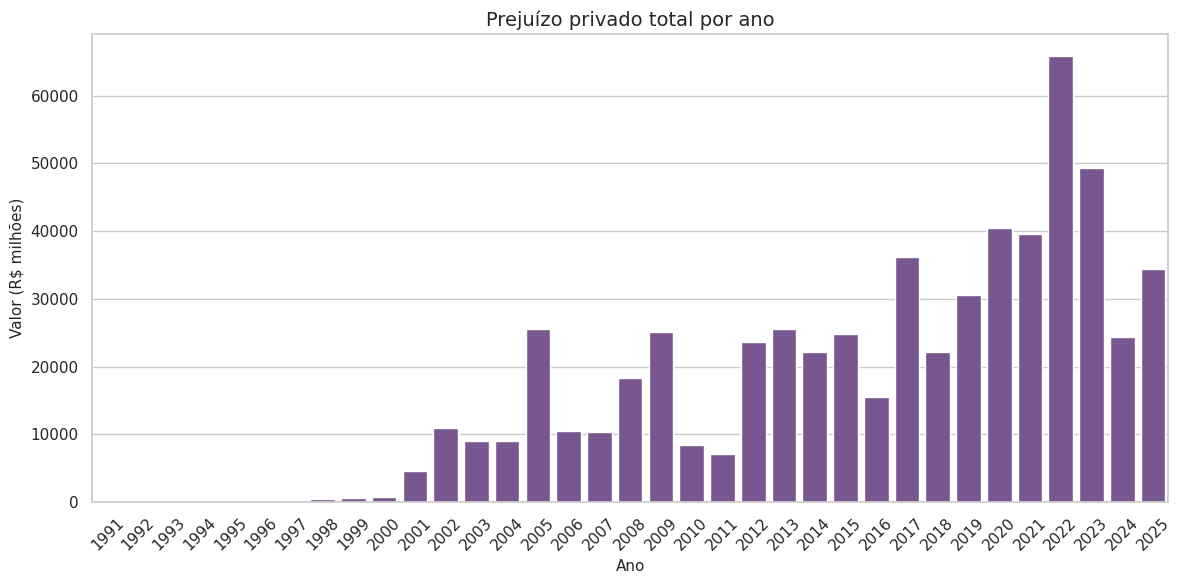

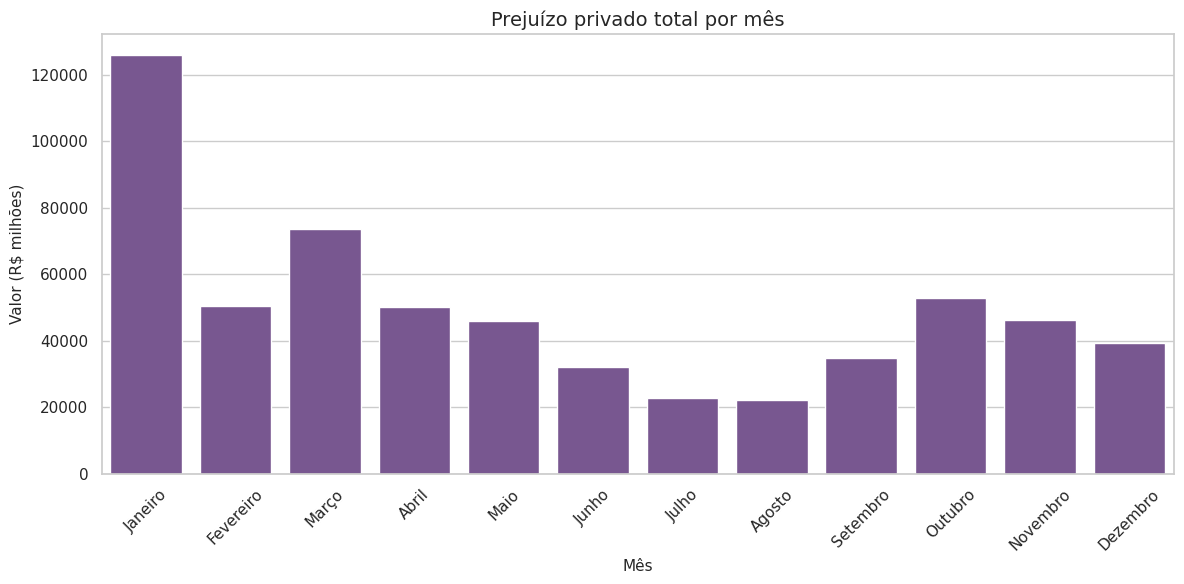

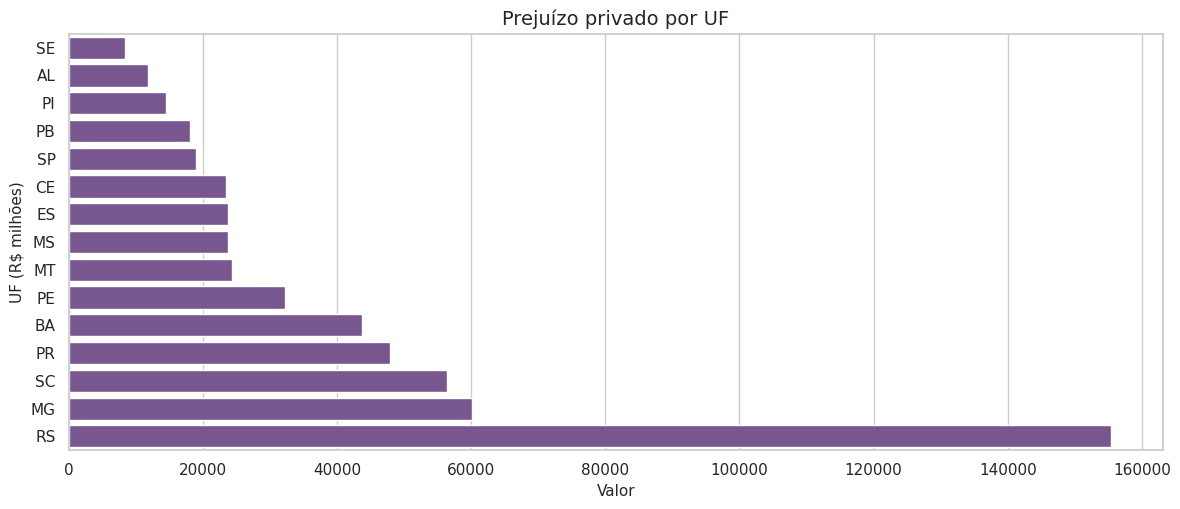

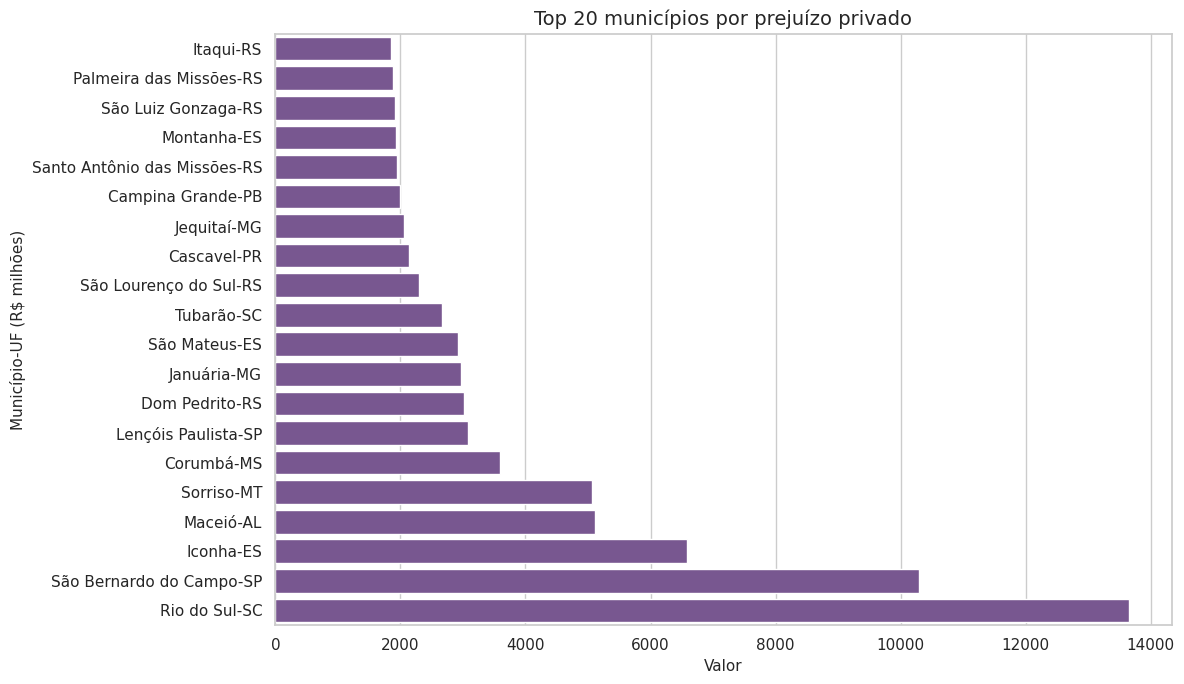

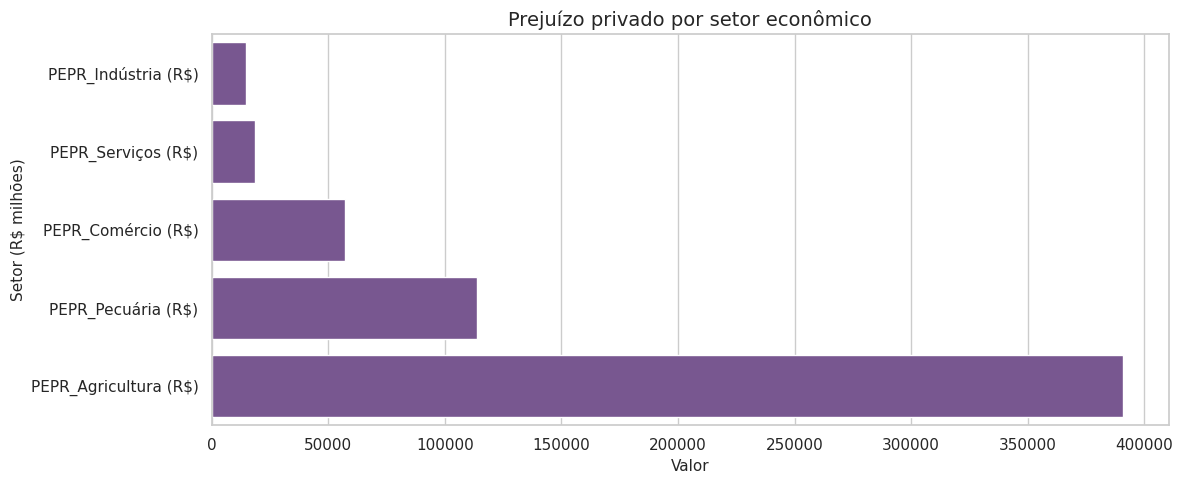

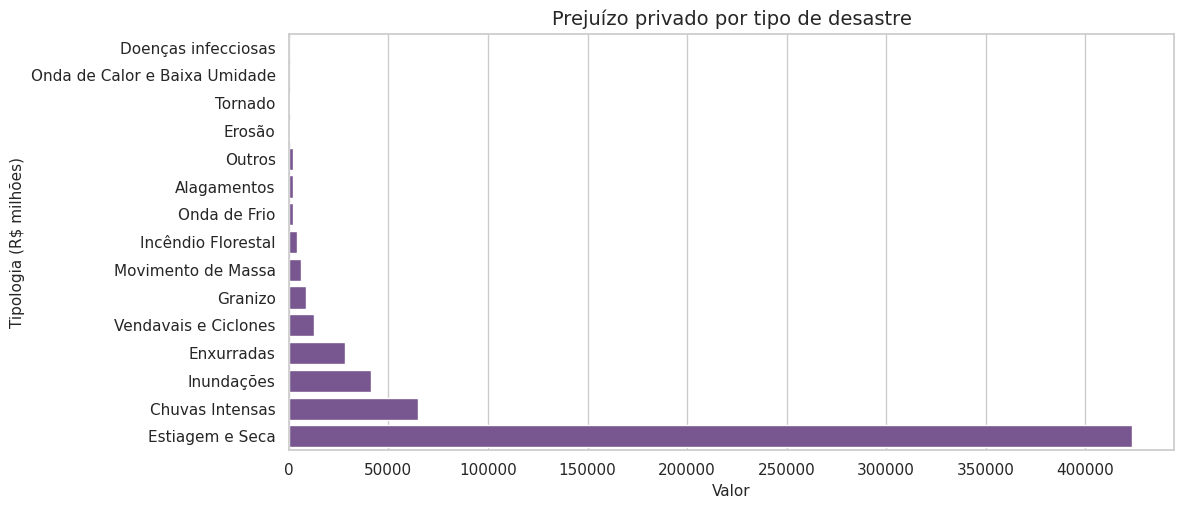

In [22]:
publico_ano = (
    agg_sum("ano_evento", "PEPL_total_publico", "prejuizo_publico")
    .dropna()
    .sort_values("ano_evento")
)
publico_mes = agg_sum("mes_nome", "PEPL_total_publico", "prejuizo_publico")
publico_mes["mes_nome"] = pd.Categorical(
    publico_mes["mes_nome"], categories=MESES_ORDEM, ordered=True
)
publico_mes = publico_mes.sort_values("mes_nome")
publico_uf = agg_sum("Sigla_UF", "PEPL_total_publico", "prejuizo_publico")
publico_municipio = agg_sum("municipio_uf", "PEPL_total_publico", "prejuizo_publico")
publico_servico = (
    df_prejuizo_publico_long.groupby("servico_publico", observed=True)["valor"]
    .sum()
    .reset_index(name="prejuizo_publico")
)
publico_tipo = agg_sum("descricao_tipologia", "PEPL_total_publico", "prejuizo_publico")

privado_ano = (
    agg_sum("ano_evento", "PEPR_total_privado", "prejuizo_privado")
    .dropna()
    .sort_values("ano_evento")
)
privado_mes = agg_sum("mes_nome", "PEPR_total_privado", "prejuizo_privado")
privado_mes["mes_nome"] = pd.Categorical(
    privado_mes["mes_nome"], categories=MESES_ORDEM, ordered=True
)
privado_mes = privado_mes.sort_values("mes_nome")
privado_uf = agg_sum("Sigla_UF", "PEPR_total_privado", "prejuizo_privado")
privado_municipio = agg_sum("municipio_uf", "PEPR_total_privado", "prejuizo_privado")
privado_setor = (
    df_prejuizo_privado_long.groupby("setor_privado", observed=True)["valor"]
    .sum()
    .reset_index(name="prejuizo_privado")
)
privado_tipo = agg_sum("descricao_tipologia", "PEPR_total_privado", "prejuizo_privado")

plot_bar(
    publico_ano,
    "ano_evento",
    "prejuizo_publico",
    "Prejuízo público total por ano",
    "Ano",
    "Valor",
    money=True,
)
plot_bar(
    publico_mes,
    "mes_nome",
    "prejuizo_publico",
    "Prejuízo público total por mês",
    "Mês",
    "Valor",
    money=True,
)
plot_bar(
    publico_uf,
    "Sigla_UF",
    "prejuizo_publico",
    "Prejuízo público por UF",
    "Valor",
    "UF",
    horizontal=True,
    top=15,
    money=True,
)
plot_bar(
    publico_municipio,
    "municipio_uf",
    "prejuizo_publico",
    "Top 20 municípios por prejuízo público",
    "Valor",
    "Município-UF",
    horizontal=True,
    top=20,
    money=True,
)
plot_bar(
    publico_servico,
    "servico_publico",
    "prejuizo_publico",
    "Prejuízo público por serviço essencial",
    "Valor",
    "Serviço",
    horizontal=True,
    money=True,
)
plot_bar(
    publico_tipo,
    "descricao_tipologia",
    "prejuizo_publico",
    "Prejuízo público por tipo de desastre",
    "Valor",
    "Tipologia",
    horizontal=True,
    top=15,
    money=True,
)

plot_bar(
    privado_ano,
    "ano_evento",
    "prejuizo_privado",
    "Prejuízo privado total por ano",
    "Ano",
    "Valor",
    money=True,
    color="#7A4E99",
)
plot_bar(
    privado_mes,
    "mes_nome",
    "prejuizo_privado",
    "Prejuízo privado total por mês",
    "Mês",
    "Valor",
    money=True,
    color="#7A4E99",
)
plot_bar(
    privado_uf,
    "Sigla_UF",
    "prejuizo_privado",
    "Prejuízo privado por UF",
    "Valor",
    "UF",
    horizontal=True,
    top=15,
    money=True,
    color="#7A4E99",
)
plot_bar(
    privado_municipio,
    "municipio_uf",
    "prejuizo_privado",
    "Top 20 municípios por prejuízo privado",
    "Valor",
    "Município-UF",
    horizontal=True,
    top=20,
    money=True,
    color="#7A4E99",
)
plot_bar(
    privado_setor,
    "setor_privado",
    "prejuizo_privado",
    "Prejuízo privado por setor econômico",
    "Valor",
    "Setor",
    horizontal=True,
    money=True,
    color="#7A4E99",
)
plot_bar(
    privado_tipo,
    "descricao_tipologia",
    "prejuizo_privado",
    "Prejuízo privado por tipo de desastre",
    "Valor",
    "Tipologia",
    horizontal=True,
    top=15,
    money=True,
    color="#7A4E99",
)


In [23]:
publico_servico_top = publico_servico.sort_values(
    "prejuizo_publico", ascending=False
).iloc[0]
privado_setor_top = privado_setor.sort_values("prejuizo_privado", ascending=False).iloc[
    0
]
publico_uf_top = publico_uf.sort_values("prejuizo_publico", ascending=False).iloc[0]
privado_uf_top = privado_uf.sort_values("prejuizo_privado", ascending=False).iloc[0]

display(
    Markdown(f"""
**Observações**

- O serviço público mais impactado é **{publico_servico_top["servico_publico"]}**, com **{dinheiro(publico_servico_top["prejuizo_publico"])}**.
- O setor privado mais impactado é **{privado_setor_top["setor_privado"]}**, com **{dinheiro(privado_setor_top["prejuizo_privado"])}**.
- A UF líder em prejuízo público é **{publico_uf_top["Sigla_UF"]}**; em prejuízo privado, **{privado_uf_top["Sigla_UF"]}**.
- A comparação entre público e privado sugere que o dashboard deve permitir alternar entre serviço essencial, setor econômico e território.
""")
)



**Observações**

- O serviço público mais impactado é **PEPL_Abast de água pot(R$)**, com **R$ 36.12 bi**.
- O setor privado mais impactado é **PEPR_Agricultura (R$)**, com **R$ 391.00 bi**.
- A UF líder em prejuízo público é **PB**; em prejuízo privado, **RS**.
- A comparação entre público e privado sugere que o dashboard deve permitir alternar entre serviço essencial, setor econômico e território.


## 13. Cruzamento com El Niño e La Niña

Os eventos ENSO são expandidos para anos. Quando mais de um evento cobre o mesmo ano, é mantido o fenômeno de maior `intensidade_rank`; em empate, fica o primeiro registro do arquivo. Anos sem evento no CSV são classificados como `Neutro`. Essa regra é simples e adequada para exploração visual.

,ano_evento,fenomeno_enso,intensidade_enso,registros,obitos,afetados_diretos,danos_materiais,prejuizo_publico,prejuizo_privado,prejuizo_total
0,1991,El Niño,Strong,403,36,21435,0.00,0.00,0.00,0.00
1,1992,El Niño,Strong,590,14,63989,0.00,0.00,0.00,0.00
2,1993,Neutro,Neutro,1324,16,11050,0.00,0.00,0.00,0.00
3,1994,El Niño,Moderate,231,4,6666,0.00,0.00,0.00,0.00
4,1995,El Niño,Moderate,818,35,87440,"28,988,151.78","11,844,177.96","204,206,419.69","216,050,597.65"
5,1996,La Niña,Moderate,490,14,9321,"324,884,976.58","86,661.79","74,990,094.53","75,076,756.32"
6,1997,El Niño,Very Strong,748,13,21088,"525,534,618.59","47,462,220.37","162,576,255.38","210,038,475.75"
7,1998,El Niño,Very Strong,1178,10,63484,"451,801,057.84","152,194,009.25","436,831,095.37","589,025,104.62"
8,1999,La Niña,Strong,741,107,25687,"307,794,023.17","38,476,068.66","578,854,090.69","617,330,159.35"
9,2000,La Niña,Strong,595,61,133202,"1,588,011,750.15","199,481,236.03","697,113,523.20","896,594,759.22"


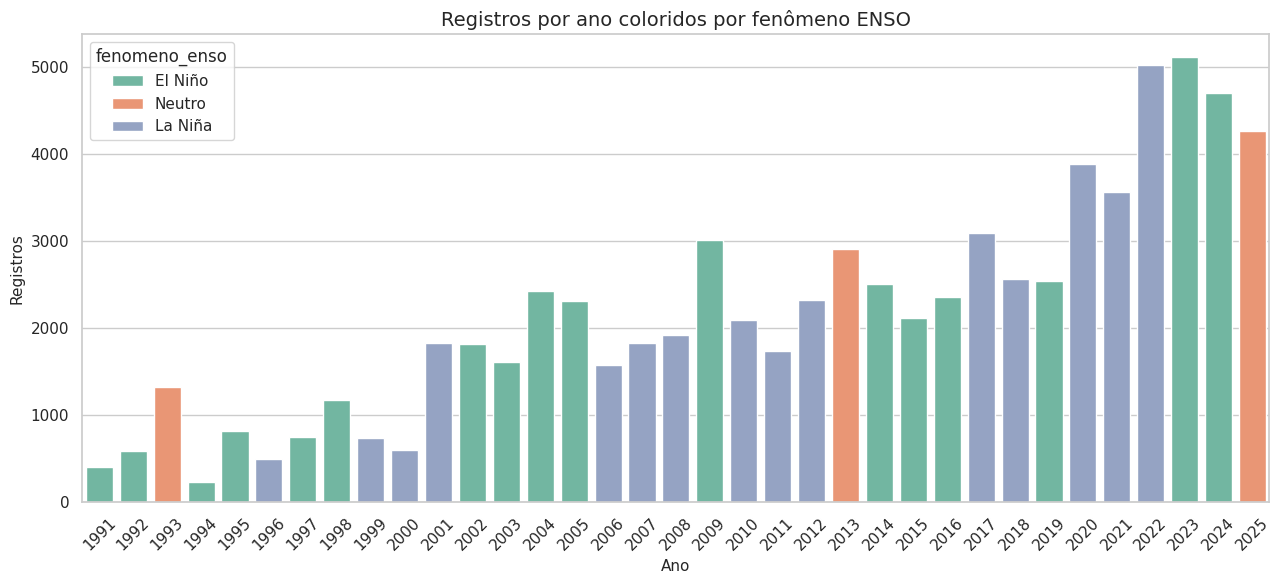

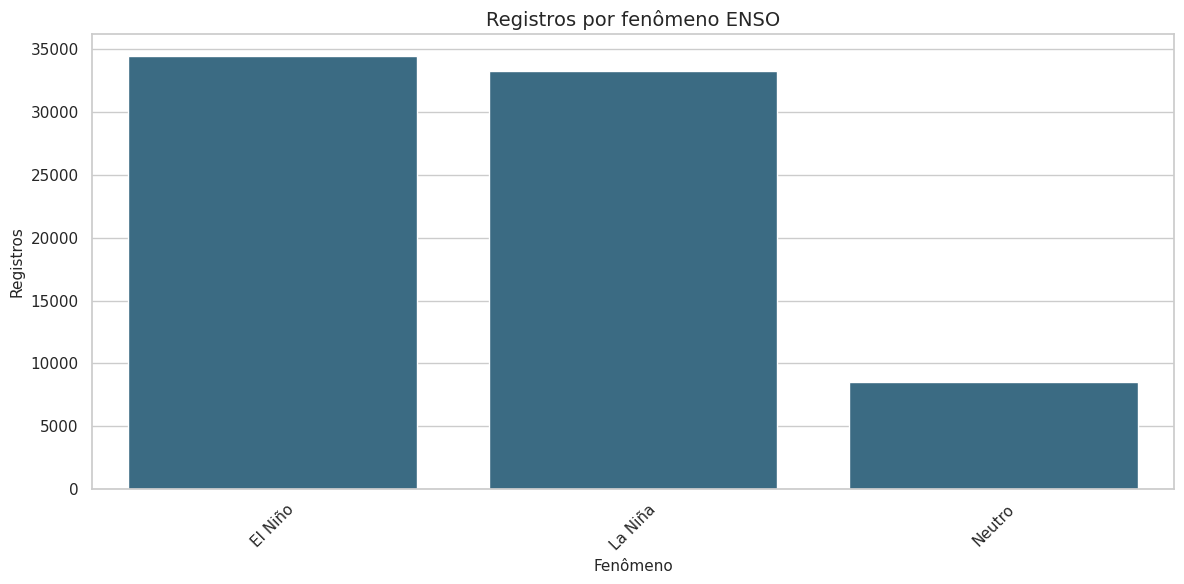

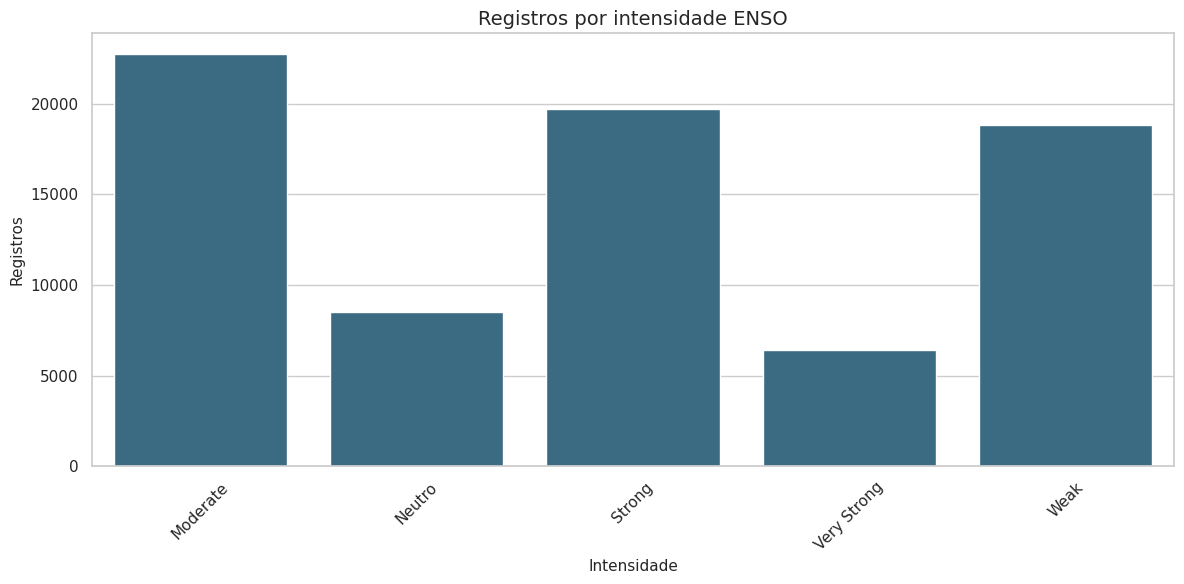

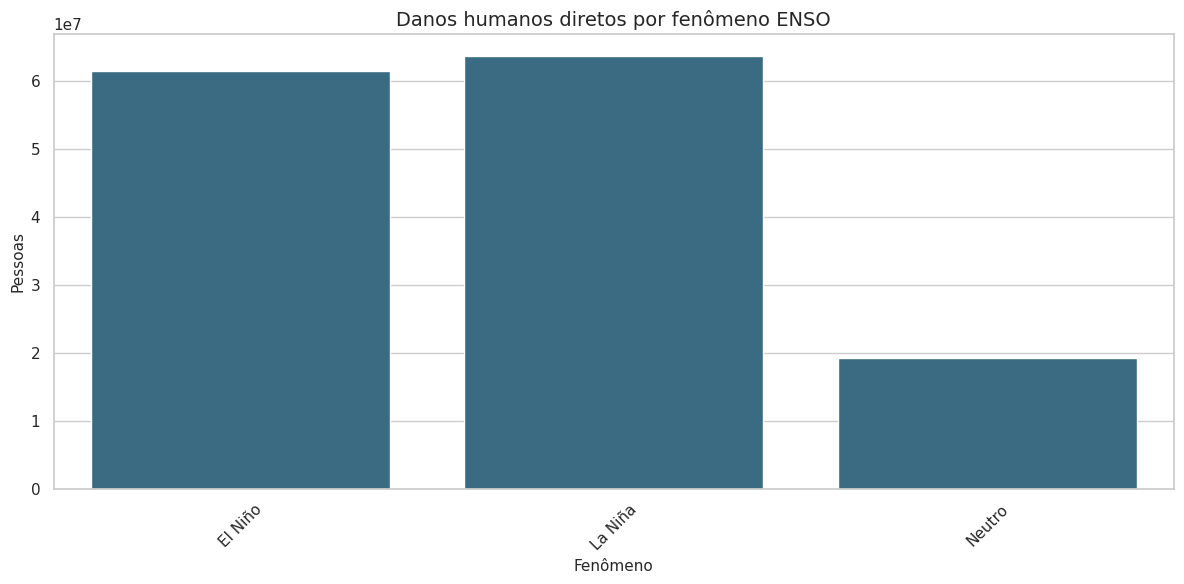

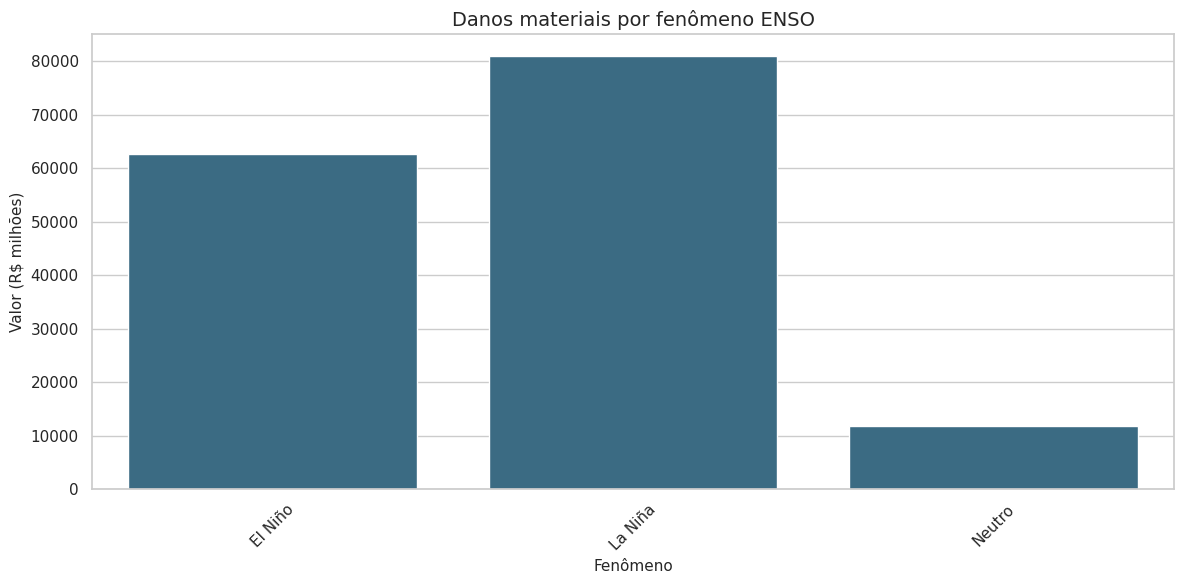

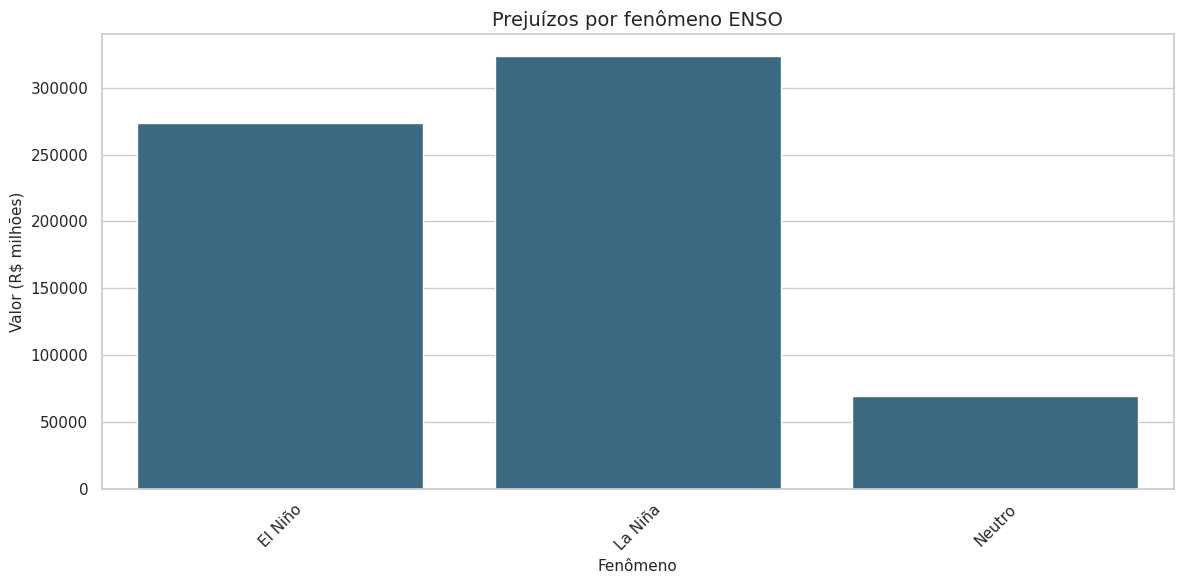

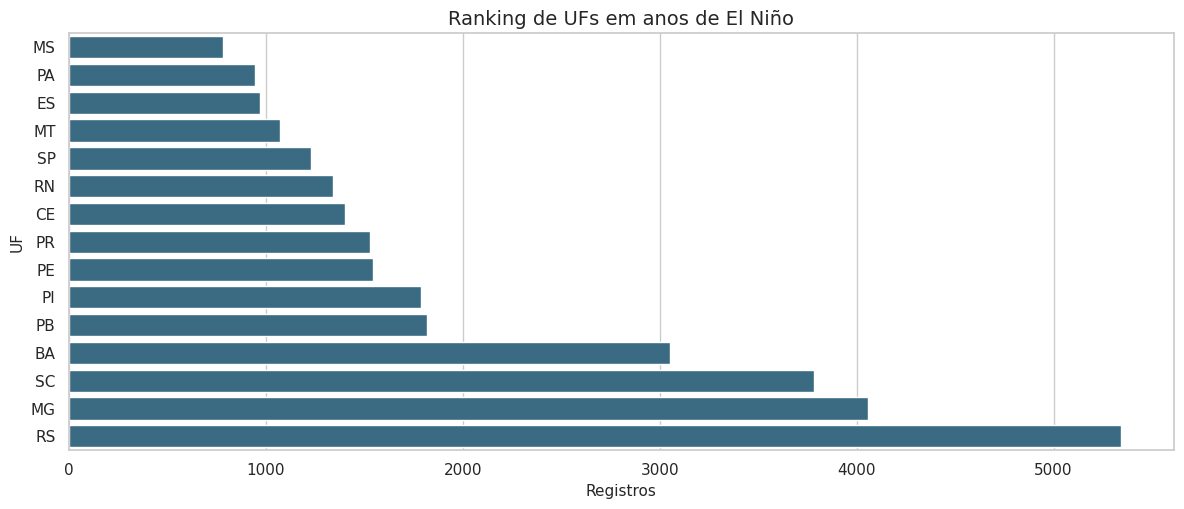

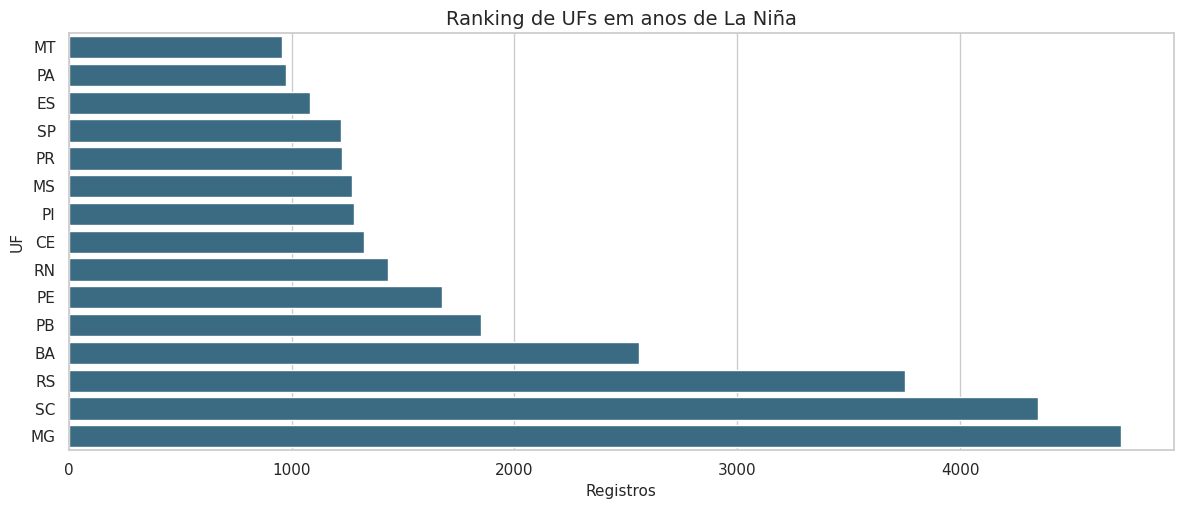

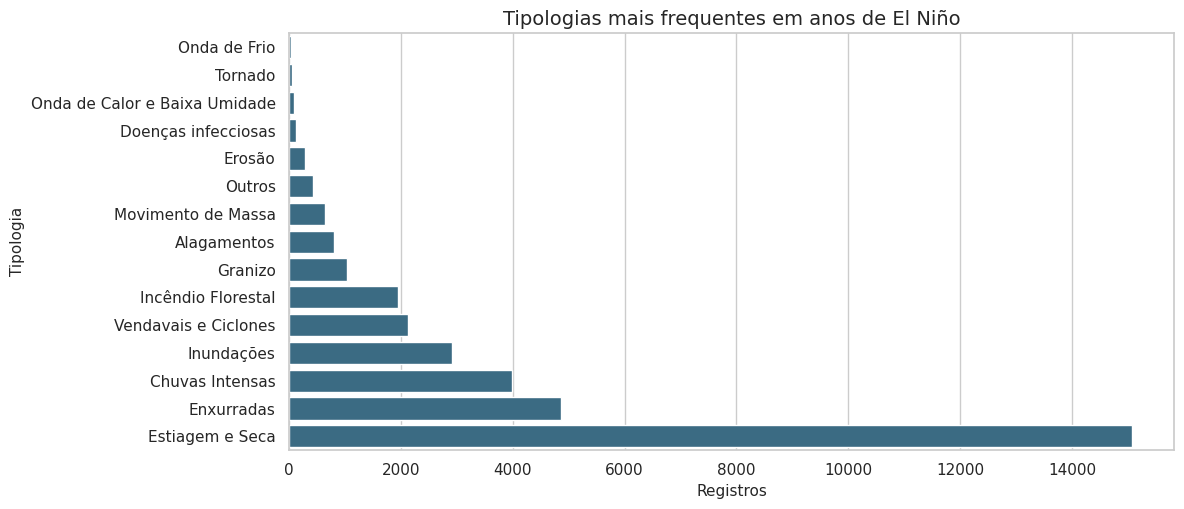

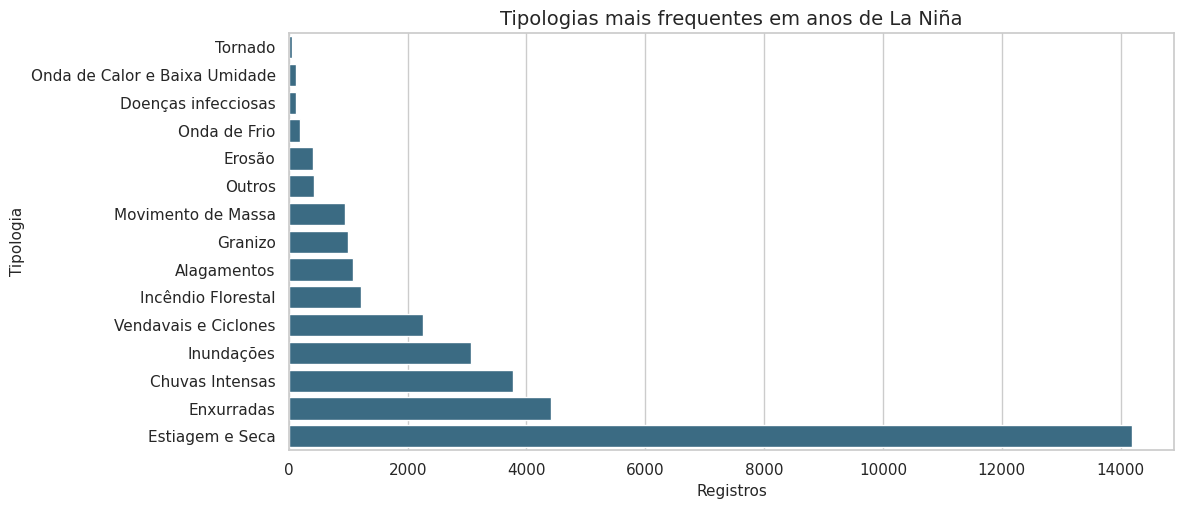

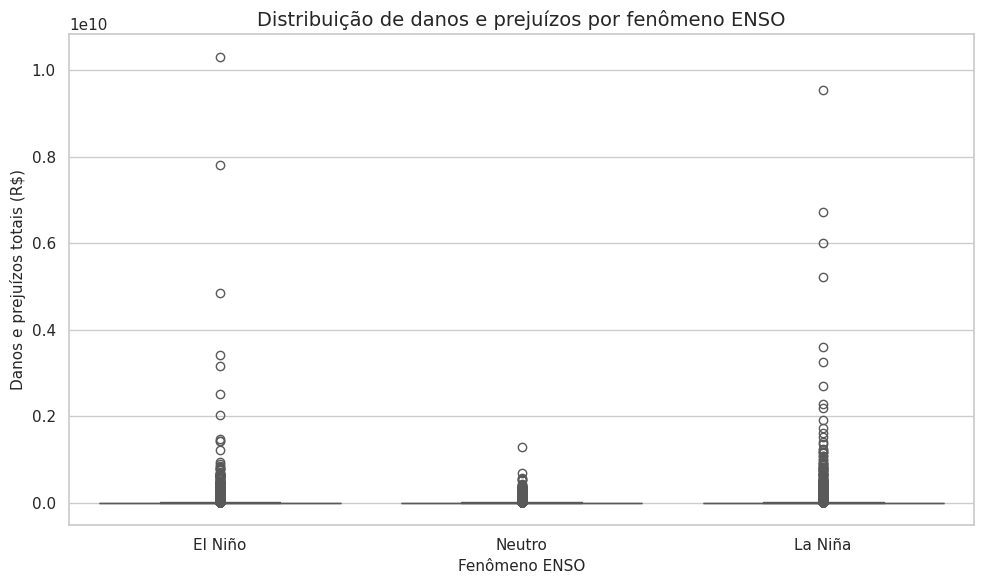

In [26]:
enso_expandido = []
for _, row in df_enso_raw.iterrows():
    for ano in range(int(row["ano_inicio"]), int(row["ano_fim"]) + 1):
        enso_expandido.append(
            {
                "ano_evento": ano,
                "periodo": row["periodo"],
                "fenomeno_enso": row["fenomeno"],
                "intensidade_enso": row["intensidade"],
                "intensidade_rank": row["intensidade_rank"],
                "sinal_oni": row["sinal_oni"],
            }
        )

df_enso_ano = (
    pd.DataFrame(enso_expandido)
    .sort_values(["ano_evento", "intensidade_rank"], ascending=[True, False])
    .drop_duplicates("ano_evento", keep="first")
)

anos_atlas = pd.DataFrame(
    {"ano_evento": sorted(df_analitico["ano_evento"].dropna().astype(int).unique())}
)
df_enso_ano = anos_atlas.merge(df_enso_ano, on="ano_evento", how="left")
df_enso_ano["fenomeno_enso"] = df_enso_ano["fenomeno_enso"].fillna("Neutro")
df_enso_ano["intensidade_enso"] = df_enso_ano["intensidade_enso"].fillna("Neutro")
df_enso_ano["intensidade_rank"] = df_enso_ano["intensidade_rank"].fillna(0).astype(int)
df_enso_ano["sinal_oni"] = df_enso_ano["sinal_oni"].fillna(0).astype(int)

df_analitico = df_analitico.merge(df_enso_ano, on="ano_evento", how="left")
for coluna, valor in {
    "fenomeno_enso": "Neutro",
    "intensidade_enso": "Neutro",
    "intensidade_rank": 0,
    "sinal_oni": 0,
}.items():
    df_analitico[coluna] = df_analitico[coluna].fillna(valor)

tabela_enso_anual = (
    df_analitico.groupby(
        ["ano_evento", "fenomeno_enso", "intensidade_enso"], observed=True
    )
    .agg(
        registros=("Protocolo_S2iD", "count"),
        obitos=("DH_MORTOS", "sum"),
        afetados_diretos=("DH_total_danos_humanos_diretos", "sum"),
        danos_materiais=("DM_total_danos_materiais", "sum"),
        prejuizo_publico=("PEPL_total_publico", "sum"),
        prejuizo_privado=("PEPR_total_privado", "sum"),
        prejuizo_total=("prejuizo_total", "sum"),
    )
    .reset_index()
    .sort_values("ano_evento")
)
display(tabela_enso_anual)

fig, ax = plt.subplots(figsize=(13, 6))
sns.barplot(
    data=tabela_enso_anual, x="ano_evento", y="registros", hue="fenomeno_enso", ax=ax
)
ax.set_title("Registros por ano coloridos por fenômeno ENSO")
ax.set_xlabel("Ano")
ax.set_ylabel("Registros")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()
plt.close(fig)

registros_fenomeno = agg_count("fenomeno_enso")
registros_intensidade = agg_count("intensidade_enso")
humanos_fenomeno = agg_sum(
    "fenomeno_enso", "DH_total_danos_humanos_diretos", "afetados"
)
danos_fenomeno = agg_sum("fenomeno_enso", "DM_total_danos_materiais", "danos_materiais")
prejuizos_fenomeno = agg_sum("fenomeno_enso", "prejuizo_total", "prejuizo_total")

plot_bar(
    registros_fenomeno,
    "fenomeno_enso",
    "registros",
    "Registros por fenômeno ENSO",
    "Fenômeno",
    "Registros",
)
plot_bar(
    registros_intensidade,
    "intensidade_enso",
    "registros",
    "Registros por intensidade ENSO",
    "Intensidade",
    "Registros",
)
plot_bar(
    humanos_fenomeno,
    "fenomeno_enso",
    "afetados",
    "Danos humanos diretos por fenômeno ENSO",
    "Fenômeno",
    "Pessoas",
)
plot_bar(
    danos_fenomeno,
    "fenomeno_enso",
    "danos_materiais",
    "Danos materiais por fenômeno ENSO",
    "Fenômeno",
    "Valor",
    money=True,
)
plot_bar(
    prejuizos_fenomeno,
    "fenomeno_enso",
    "prejuizo_total",
    "Prejuízos por fenômeno ENSO",
    "Fenômeno",
    "Valor",
    money=True,
)

ranking_uf_el_nino = (
    df_analitico.query("fenomeno_enso == 'El Niño'")
    .groupby("Sigla_UF", observed=True)
    .size()
    .reset_index(name="registros")
)
ranking_uf_la_nina = (
    df_analitico.query("fenomeno_enso == 'La Niña'")
    .groupby("Sigla_UF", observed=True)
    .size()
    .reset_index(name="registros")
)
tipo_el_nino = (
    df_analitico.query("fenomeno_enso == 'El Niño'")
    .groupby("descricao_tipologia", observed=True)
    .size()
    .reset_index(name="registros")
)
tipo_la_nina = (
    df_analitico.query("fenomeno_enso == 'La Niña'")
    .groupby("descricao_tipologia", observed=True)
    .size()
    .reset_index(name="registros")
)

plot_bar(
    ranking_uf_el_nino,
    "Sigla_UF",
    "registros",
    "Ranking de UFs em anos de El Niño",
    "Registros",
    "UF",
    horizontal=True,
    top=15,
)
plot_bar(
    ranking_uf_la_nina,
    "Sigla_UF",
    "registros",
    "Ranking de UFs em anos de La Niña",
    "Registros",
    "UF",
    horizontal=True,
    top=15,
)
plot_bar(
    tipo_el_nino,
    "descricao_tipologia",
    "registros",
    "Tipologias mais frequentes em anos de El Niño",
    "Registros",
    "Tipologia",
    horizontal=True,
    top=15,
)
plot_bar(
    tipo_la_nina,
    "descricao_tipologia",
    "registros",
    "Tipologias mais frequentes em anos de La Niña",
    "Registros",
    "Tipologia",
    horizontal=True,
    top=15,
)

enso_box = df_analitico[["fenomeno_enso", "danos_e_prejuizos_total"]].copy()
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=enso_box, x="fenomeno_enso", y="danos_e_prejuizos_total", ax=ax)
ax.set_title("Distribuição de danos e prejuízos por fenômeno ENSO")
ax.set_xlabel("Fenômeno ENSO")
ax.set_ylabel("Danos e prejuízos totais (R$)")
plt.tight_layout()
plt.show()
plt.close(fig)


In [28]:
ano_extremo_registros = tabela_enso_anual.sort_values(
    "registros", ascending=False
).iloc[0]
fenomeno_reg_top = registros_fenomeno.sort_values("registros", ascending=False).iloc[0]
fenomeno_prej_top = prejuizos_fenomeno.sort_values(
    "prejuizo_total", ascending=False
).iloc[0]

display(
    Markdown(
        f"""
**Observações**

- Visualmente, os totais variam entre **El Niño**, **La Niña** e **Neutro**, mas essa comparação é exploratória e não causal.
- O ano com mais registros é **{int(ano_extremo_registros["ano_evento"])}**, classificado como **{ano_extremo_registros["fenomeno_enso"]} / {ano_extremo_registros["intensidade_enso"]}**, com **{int(ano_extremo_registros["registros"]):,}** registros.
- O fenômeno com mais registros agregados é **{fenomeno_reg_top["fenomeno_enso"]}**, com **{int(fenomeno_reg_top["registros"]):,}** registros.
- O fenômeno com maior prejuízo total agregado é **{fenomeno_prej_top["fenomeno_enso"]}**, com **{dinheiro(fenomeno_prej_top["prejuizo_total"])}**.
""".replace(",", ".")
    )
)



**Observações**

- Visualmente. os totais variam entre **El Niño**. **La Niña** e **Neutro**. mas essa comparação é exploratória e não causal.
- O ano com mais registros é **2023**. classificado como **El Niño / Strong**. com **5.115** registros.
- O fenômeno com mais registros agregados é **El Niño**. com **34.455** registros.
- O fenômeno com maior prejuízo total agregado é **La Niña**. com **R$ 323.65 bi**.


## 14. Síntese dos principais achados

A síntese abaixo consolida métricas calculadas no notebook para orientar quais filtros, KPIs e rankings devem ganhar prioridade no dashboard.

In [30]:
total_registros = len(df_analitico)
municipio_reg_top = registros_municipio.sort_values("registros", ascending=False).iloc[
    0
]
obito_municipio_top = obitos_municipio.sort_values("obitos", ascending=False).iloc[0]
danos_municipio_top = danos_municipio.sort_values(
    "danos_materiais", ascending=False
).iloc[0]
prejuizo_total_uf = (
    agg_sum("Sigla_UF", "prejuizo_total", "prejuizo_total")
    .sort_values("prejuizo_total", ascending=False)
    .iloc[0]
)
prejuizo_total_mun = (
    agg_sum("municipio_uf", "prejuizo_total", "prejuizo_total")
    .sort_values("prejuizo_total", ascending=False)
    .iloc[0]
)
tipologia_prejuizo_top = (
    agg_sum("descricao_tipologia", "prejuizo_total", "prejuizo_total")
    .sort_values("prejuizo_total", ascending=False)
    .iloc[0]
)

sintese = f"""
**Principais achados**

1. A base contém **{total_registros:,}** registros nacionais no período **{int(df_analitico["ano_evento"].min())}–{int(df_analitico["ano_evento"].max())}**.
2. O ano com mais registros é **{int(ano_top["ano_evento"])}**, com **{int(ano_top["registros"]):,}** registros.
3. A UF com mais registros é **{uf_top["Sigla_UF"]}**, com **{int(uf_top["registros"]):,}** registros.
4. O município com mais registros é **{municipio_reg_top["municipio_uf"]}**, com **{int(municipio_reg_top["registros"]):,}** registros.
5. A UF com maior soma de óbitos é **{obito_uf_top["Sigla_UF"]}**, com **{int(obito_uf_top["obitos"]):,}** óbitos.
6. O município com maior soma de óbitos é **{obito_municipio_top["municipio_uf"]}**, com **{int(obito_municipio_top["obitos"]):,}** óbitos.
7. A UF com maior dano material é **{danos_uf_top["Sigla_UF"]}**, com **{dinheiro(danos_uf_top["danos_materiais"])}**.
8. O município com maior dano material é **{danos_municipio_top["municipio_uf"]}**, com **{dinheiro(danos_municipio_top["danos_materiais"])}**.
9. A UF com maior prejuízo total é **{prejuizo_total_uf["Sigla_UF"]}**, com **{dinheiro(prejuizo_total_uf["prejuizo_total"])}**; o município líder é **{prejuizo_total_mun["municipio_uf"]}**, com **{dinheiro(prejuizo_total_mun["prejuizo_total"])}**.
10. A tipologia dominante em registros é **{tipologia_top["descricao_tipologia"]}**; em prejuízo total, destaca-se **{tipologia_prejuizo_top["descricao_tipologia"]}**, com **{dinheiro(tipologia_prejuizo_top["prejuizo_total"])}**.

**Observações para o dashboard**

- KPIs nacionais de registros, óbitos, afetados, danos materiais, prejuízo público, prejuízo privado e prejuízo total.
- Filtros por ano, região, UF, município, grupo, tipologia, status e fenômeno ENSO.
- Rankings territoriais com alternância entre registros, danos humanos e valores monetários.
- Série temporal anual colorida por fenômeno ENSO com aviso de análise não causal.
- Páginas ou abas separadas para danos humanos, danos materiais, prejuízos públicos, prejuízos privados e análise ENSO.
"""
display(Markdown(sintese.replace(",", ".")))



**Principais achados**

1. A base contém **76.191** registros nacionais no período **1991–2025**.
2. O ano com mais registros é **2023**. com **5.115** registros.
3. A UF com mais registros é **RS**. com **10.091** registros.
4. O município com mais registros é **Campo Grande-MS**. com **223** registros.
5. A UF com maior soma de óbitos é **RJ**. com **1.807** óbitos.
6. O município com maior soma de óbitos é **Petrópolis-RJ**. com **516** óbitos.
7. A UF com maior dano material é **RJ**. com **R$ 18.19 bi**.
8. O município com maior dano material é **Maceió-AL**. com **R$ 11.40 bi**.
9. A UF com maior prejuízo total é **RS**. com **R$ 160.30 bi**; o município líder é **Rio do Sul-SC**. com **R$ 13.70 bi**.
10. A tipologia dominante em registros é **Estiagem e Seca**; em prejuízo total. destaca-se **Estiagem e Seca**. com **R$ 459.56 bi**.

**Observações para o dashboard**

- KPIs nacionais de registros. óbitos. afetados. danos materiais. prejuízo público. prejuízo privado e prejuízo total.
- Filtros por ano. região. UF. município. grupo. tipologia. status e fenômeno ENSO.
- Rankings territoriais com alternância entre registros. danos humanos e valores monetários.
- Série temporal anual colorida por fenômeno ENSO com aviso de análise não causal.
- Páginas ou abas separadas para danos humanos. danos materiais. prejuízos públicos. prejuízos privados e análise ENSO.
